In [1]:
import sys
from pathlib import Path
import torch

# Note: Will need to move HeFESTo_functions.py to nMELTS/utils so it will be ported properly. 

# Handle both notebook and script contexts
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook context
    repo_root = Path.cwd().parent

# Add both src and src/nMELTS to path
src_root = repo_root / "src"
nmelts_root = src_root / "nMELTS"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
if str(nmelts_root) not in sys.path:
    sys.path.insert(0, str(nmelts_root))

# Import utilities and API
from nMELTS.utils.math_utils import grid_sample, grid_sample_explicit
from nMELTS.engine.API import HeFESToAPI, HeFESToEmulatorCPU, HeFESToEmulatorGPU
from nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES
REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES = {v: k for k, v in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.items()}


print("Imports successful!")
print(f"Repository root: {repo_root}")
print(f"nMELTS root: {nmelts_root}")

# Check emulator availability
if HeFESToEmulatorCPU is None:
    print("\nNote: Pre-instantiated emulators not available (model files missing).")
    print("Create HeFESToAPI instances with valid model paths when needed.")
else:
    print("\nEmulators available:")
    print(f"  - HeFESToEmulatorCPU")
    print(f"  - HeFESToEmulatorGPU")


[INFO] Looking for HeFESTo model at: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer with value: 0.0
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPS.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer 

In [2]:
# HeFESTo PS Phase Diagram Demo - Load Simulations

import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Get repo root (from cell 1 setup)
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    repo_root = Path.cwd().parent

# Add builder path for HeFESTo functions
builder_root = repo_root / "src" / "builder"
sys.path.insert(0, str(builder_root))

from HeFESTo.HeFESTo_functions import extract_bulk_properties_from_simulation_dir, load_fort99_componentMoles 

# Define compositions for reference
compositions = {
    'harzburgite_PS': {
    'Si': 3.57887,
    'Mg': 5.64233,
    'Fe': 0.58052,
    'Ca': 0.07969,
    'Al': 0.09740,
    'Na': 0.00160,
    'Cr': 0.01960,
    'O': 13.63947
    },

    'DMM_PS': {
    'Si': 3.79222,
    'Mg': 4.88475,
    'Fe': 0.57874,
    'Ca': 0.28734,
    'Al': 0.39685,
    'Na': 0.02197,
    'Cr': 0.03813,
    'O': 14.00450
    },

    'basalt_PS': {
    'Si': 4.61116,
    'Mg': 1.33197,
    'Fe': 0.61701,
    'Ca': 1.22855,
    'Al': 1.81090,
    'Na': 0.39533,
    'Cr': 0.00508,
    'O': 15.35841
    }
}

# Load HeFESTo PS simulations - use absolute paths
hefesto_workspace = repo_root / "data" / "HeFESToWorkspace"

sim_paths = {
    'harzburgite_PS': hefesto_workspace / 'htz_PS',
    'DMM_PS': hefesto_workspace / 'DMM_PS',
    'basalt_PS': hefesto_workspace / 'basalt_PS',
}

# Dictionary to store DataFrames
sim_tables = {}
comp_tables = {}
mass_tables = {}
indexer = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer

print("Loading HeFESTo simulations...\n")

for sim_name, sim_path in sim_paths.items():
    try:
        print(f"Loading {sim_name} from {sim_path}...")
        props = extract_bulk_properties_from_simulation_dir(str(sim_path))
        comp_tables[sim_name] = load_fort99_componentMoles(str(sim_path), indexer)
        # convert component moles (B, C) to phase masses (B, P)
        _, mass_tables[sim_name] = HeFESToEmulatorCPU.isentropic_emulator.make_phase_tables(torch.tensor(comp_tables[sim_name], dtype=torch.float32))


        # Build each table section explicitly so no columns get lost in a dict update.
        n_rows = len(props['T(K)'])
        base_df = pd.DataFrame({
            'T(K)': np.asarray(props['T(K)']).reshape(n_rows),
            'P(GPa)': np.asarray(props['P(GPa)']).reshape(n_rows),
            'VS(km/s)': np.asarray(props['VS(km/s)']).reshape(n_rows),
            'VP(km/s)': np.asarray(props['VP(km/s)']).reshape(n_rows),
            'rho(g/cm^3)': np.asarray(props['rho(g/cm^3)']).reshape(n_rows),
            'VB(km/s)': np.asarray(props['VB(km/s)']).reshape(n_rows),
            'VSQ(km/s)': np.asarray(props['VSQ(km/s)']).reshape(n_rows),
            'VPQ(km/s)': np.asarray(props['VPQ(km/s)']).reshape(n_rows),
            'H(kJ/g)': np.asarray(props['H(kJ/g)']).reshape(n_rows),
            'S(J/g/K)': np.asarray(props['S(J/g/K)']).reshape(n_rows),
            'alpha(1e5_K^-1)': np.asarray(props['alpha(1e5_K^-1)']).reshape(n_rows),
            'cp(J/g/K)': np.asarray(props['cp(J/g/K)']).reshape(n_rows),
            'KS(GPa)': np.asarray(props['KS(GPa)']).reshape(n_rows),
        })

        component_df = pd.DataFrame(index=base_df.index)
        for i, comp_name in enumerate(props['component_names']):
            component_df[f'comp_{comp_name}'] = np.asarray(props['component_moles'][:, i]).reshape(n_rows)

        df = pd.concat([base_df, component_df], axis=1) #bulk_df,
        sim_tables[sim_name] = df

        print(f"  -> Loaded {len(df)} rows")
        print(f"  -> Columns: {list(df.columns)[:8]}...")
        print()

    except Exception as e:
        print(f"ERROR loading {sim_name}: {e}\n")

# Display summary
print("="*70)
print("SUMMARY OF LOADED SIMULATIONS")
print("="*70)

emulated_components = {}
emulated_mass_tables = {}

emulated_components_NN = {}
emulated_mass_tables_NN = {}

for sim_name, df in sim_tables.items():
    

    comp = compositions[sim_name]
    headers = []
    print(f"\n{sim_name} composition: {comp}")
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = np.concatenate([sim_tables[sim_name][['P(GPa)', 'S(J/g/K)']].to_numpy(), np.tile(comp_array, (sim_tables[sim_name].shape[0], 1))], axis=1)
    print(f"Input grid shape: {input_grid.shape}")

    headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', ] + headers
    #features_tensor = HeFESToEmulatorCPU.parse_input(input_grid, headers=headers)
    output = HeFESToEmulatorCPU.ForwardMB(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'phase_tables']
    )

    emulated_components[sim_name], (_, emulated_mass_tables[sim_name]) = output['component_moles'], output['phase_tables']

    outputNN = HeFESToEmulatorCPU.ForwardNN(
        torch.tensor(input_grid, dtype=torch.float32),
        headers=headers,
        outputs=['component_moles', 'phase_tables']
    )

    emulated_components_NN[sim_name], (_, emulated_mass_tables_NN[sim_name]) = outputNN['component_moles'], outputNN['phase_tables']

    print(f"\n{sim_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  P range: {df['P(GPa)'].min():.2f} - {df['P(GPa)'].max():.2f} GPa")
    print(f"  T range: {df['T(K)'].min():.0f} - {df['T(K)'].max():.0f} K")
    print(f"  Description:\n{df.describe().to_string()}")

Loading HeFESTo simulations...

Loading harzburgite_PS from c:\Git_Repositories\nMELTS\data\HeFESToWorkspace\htz_PS...
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

Loading DMM_PS from c:\Git_Repositories\nMELTS\data\HeFESToWorkspace\DMM_PS...
[WARNING] Component alpha-iron is present in fort.99 but not found in indexer!
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

Loading basalt_PS from c:\Git_Repositories\nMELTS\data\HeFESToWorkspace\basalt_PS...
[WARNING] Component mg-nal-phase is present in fort.99 but not found in indexer!
[WARNING] Component fe-nal-phase is present in fort.99 but not found in indexer!
[WARNING] Component na-nal-phase is present in fort.99 but not found in indexer!
[WARNING] Component quartz is present in fort.99 but not found in indexer!
[WARNING] Component coesite is present in fort.9

In [10]:
np.tile(comp_array, (sim_tables[sim_name].shape[0], 1)).shape

(4089, 8)

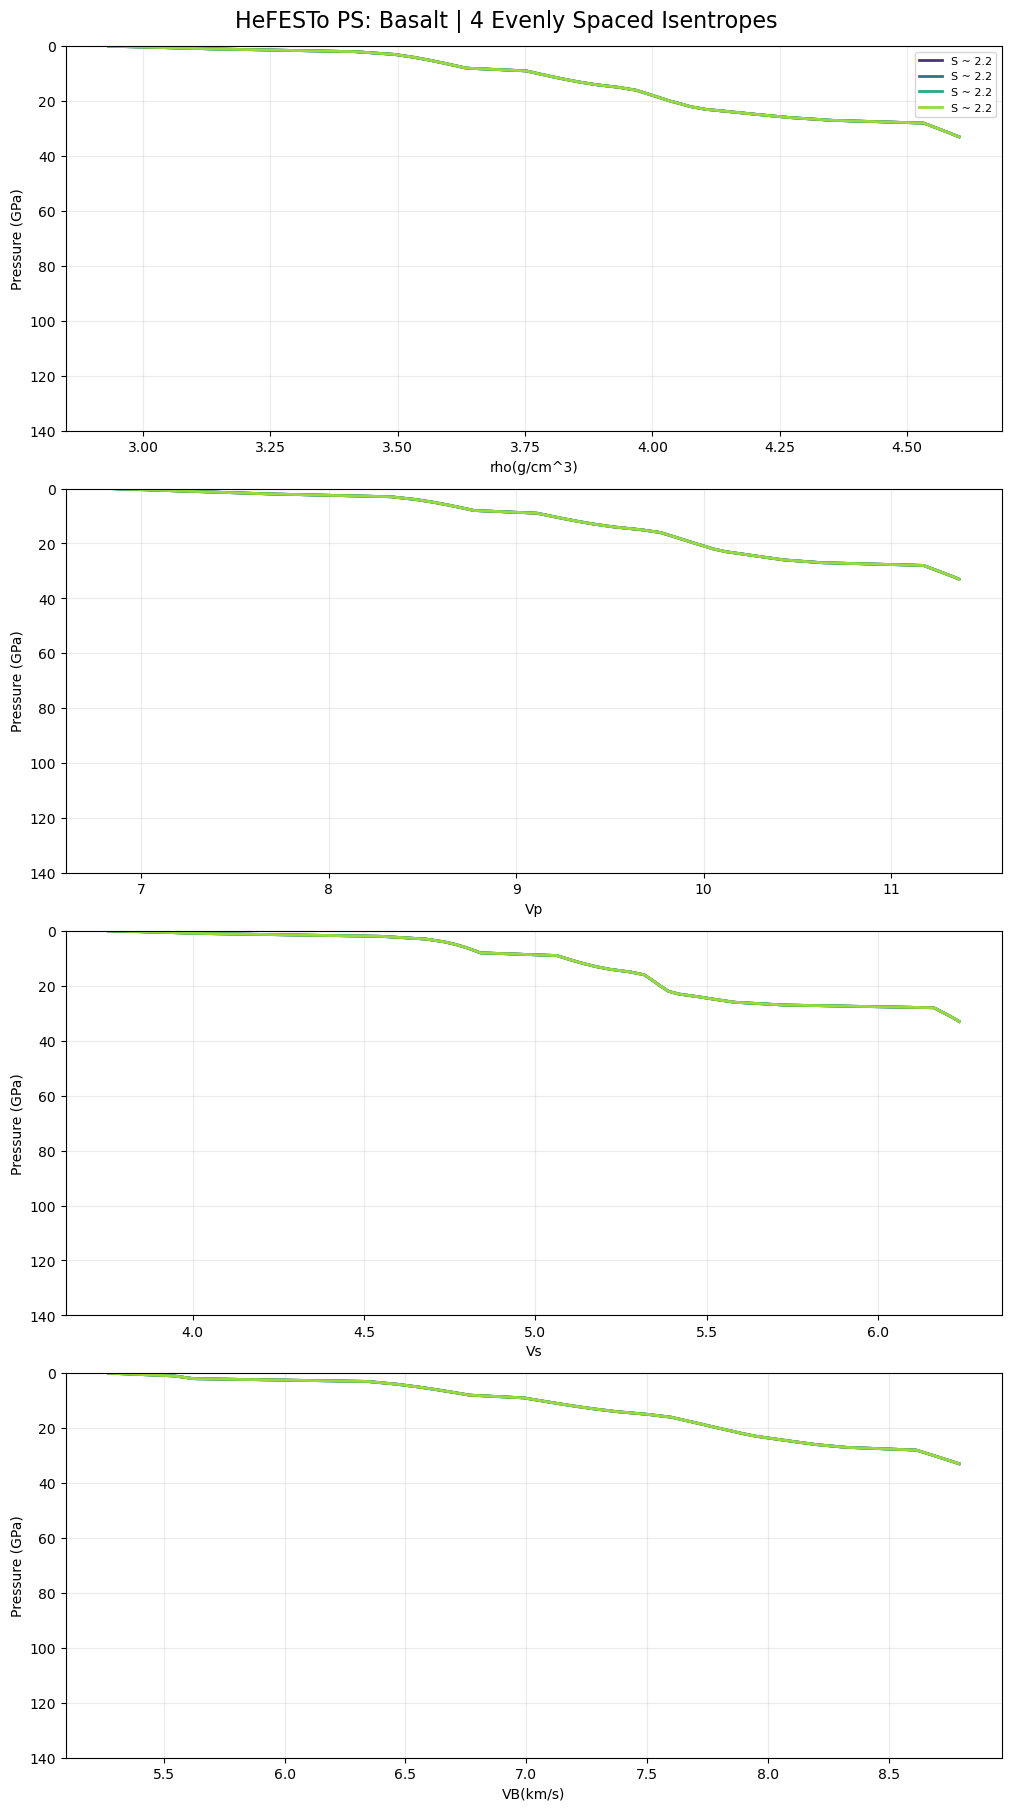

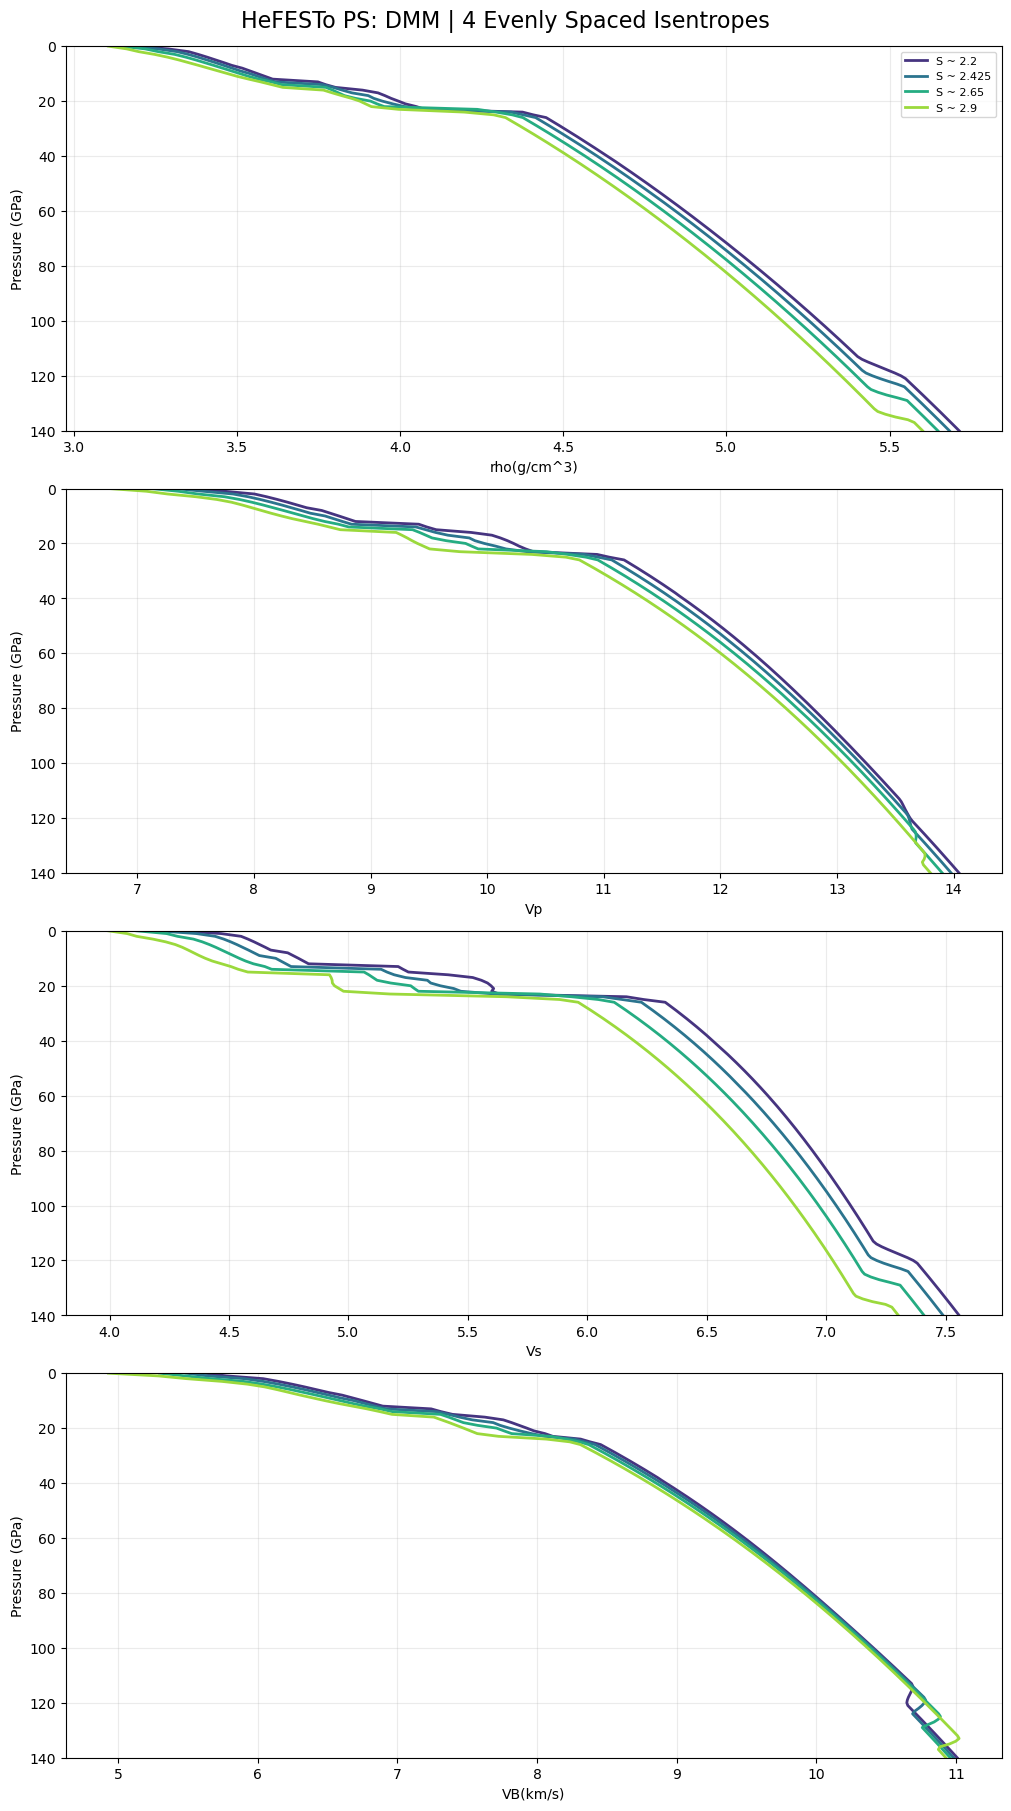

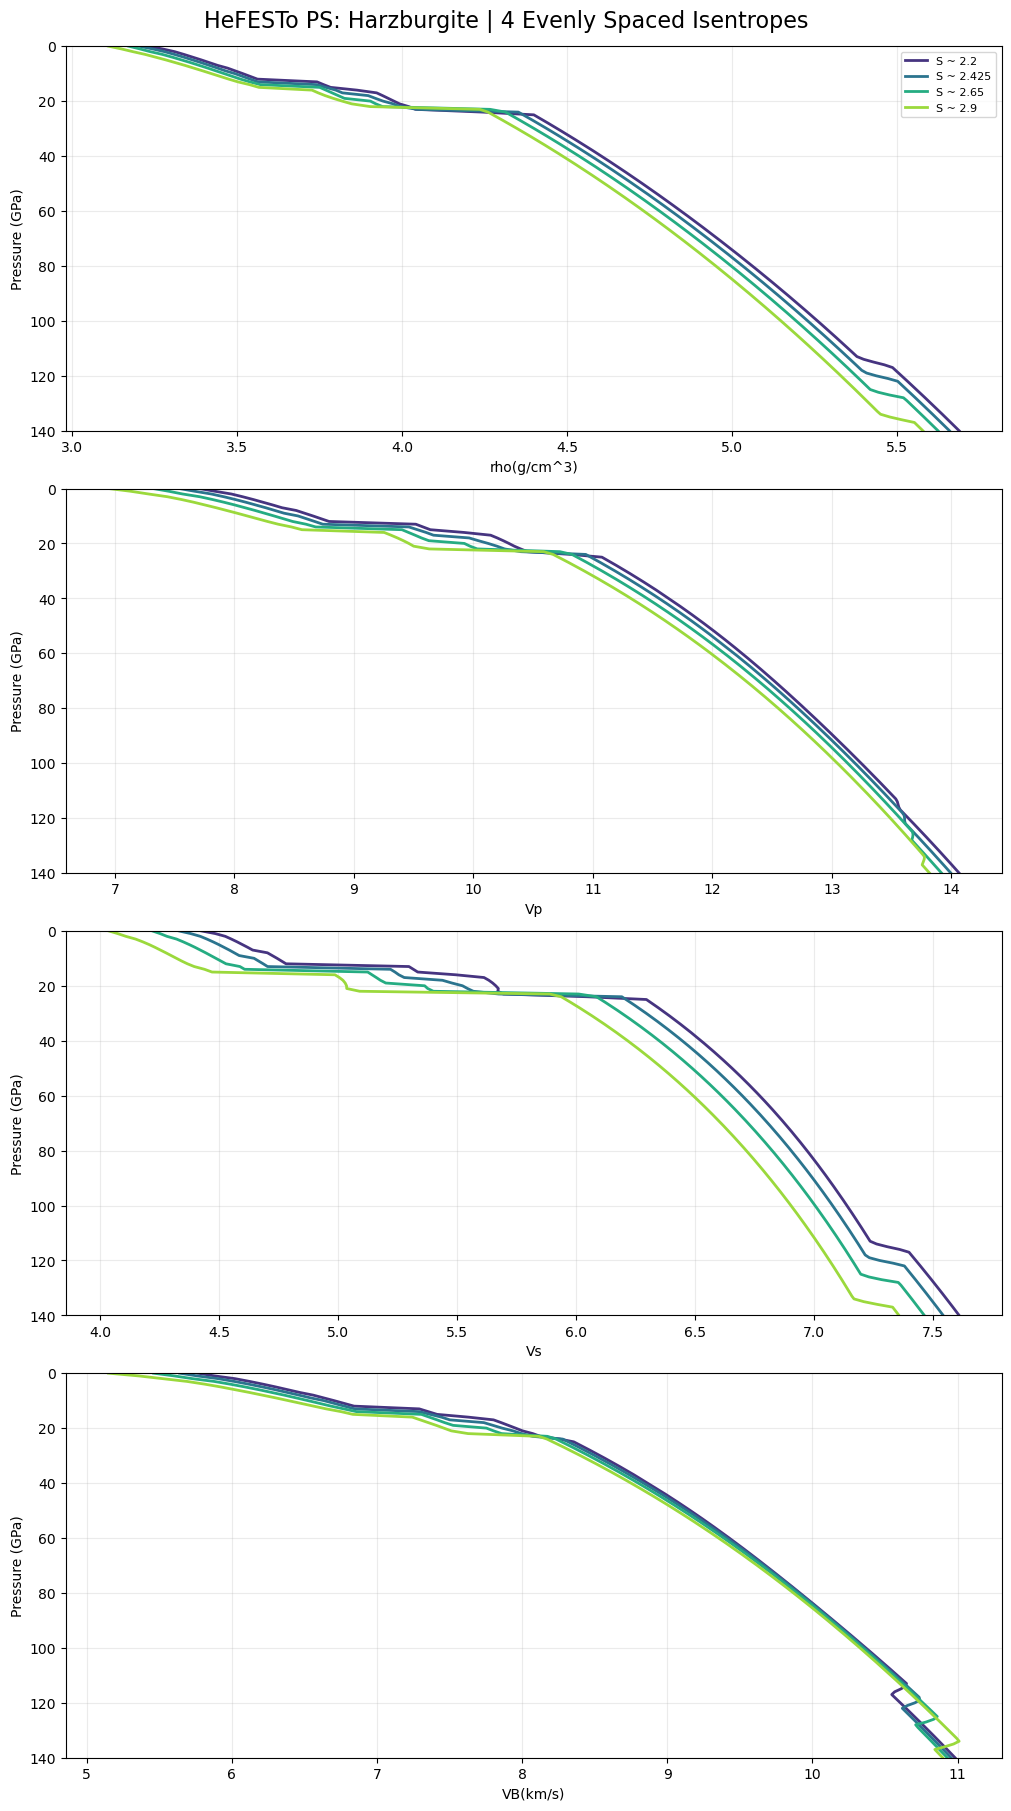

In [3]:
# Plot 5 properties for each composition in a separate 5x1 figure.
# Each composition has 29 isentropes sampled over 141 pressure points from 0 to 140 GPa.
# We select 4 evenly spaced isentropes per composition and plot property (x-axis)
# versus pressure (inverted y-axis).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'sim_tables' not in globals():
    raise RuntimeError('Cell 2 must be run first so sim_tables is available.')

composition_order = ['basalt_PS', 'DMM_PS', 'harzburgite_PS']
composition_titles = {
    'basalt_PS': 'Basalt',
    'DMM_PS': 'DMM',
    'harzburgite_PS': 'Harzburgite',
}

property_specs = [
    ('rho(g/cm^3)', ['rho(g/cm^3)', 'density']),
    ('Vp', ['Vp', 'VP(km/s)', 'vp']),
    ('Vs', ['Vs', 'VS(km/s)', 'vs']),
    ('VB(km/s)', ['VB(km/s)', 'bulk_velocity']),
]


def _resolve_column(df, candidates):
    lower_map = {str(col).lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
        lower_candidate = str(candidate).lower()
        if lower_candidate in lower_map:
            return lower_map[lower_candidate]
    raise KeyError(f'Could not resolve any of {candidates} from columns: {list(df.columns)}')


for sim_name in composition_order:
    if sim_name not in sim_tables:
        raise KeyError(f'Missing table for {sim_name}')

    df = sim_tables[sim_name].copy().reset_index(drop=True)
    pressure_col = _resolve_column(df, ['P(GPa)', 'Pressure', 'pressure'])
    entropy_col = _resolve_column(df, ['entropy', 'Entropy', 'S(J/g/K)', 'S'])

    n_pressure_points = int(pd.to_numeric(df[pressure_col], errors='coerce').nunique(dropna=True))
    if n_pressure_points <= 1 or len(df) % n_pressure_points != 0:
        raise ValueError(
            f'Could not infer isentrope block size for {sim_name}: '
            f'len(df)={len(df)}, unique pressures={n_pressure_points}'
        )

    n_isentropes = len(df) // n_pressure_points
    selected_isentropes = np.linspace(0, n_isentropes - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))

    fig, axes = plt.subplots(
        nrows=len(property_specs),
        ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    plotted_isentropes = []

    for row_idx, (property_name, candidates) in enumerate(property_specs):
        ax = axes[row_idx]
        property_col = _resolve_column(df, candidates)

        for iso_idx, isentrope_idx in enumerate(selected_isentropes):
            plotted_isentropes.append(df[entropy_col].iloc[isentrope_idx*n_pressure_points])
            start = isentrope_idx * n_pressure_points
            end = start + n_pressure_points
            chunk = df.iloc[start:end][[pressure_col, property_col, entropy_col]].copy()
            chunk = chunk.sort_values(pressure_col)

            entropy_value = float(pd.to_numeric(chunk[entropy_col], errors='coerce').mean())
            ax.plot(
                chunk[property_col],
                chunk[pressure_col],
                color=line_colors[iso_idx],
                linewidth=2.0,
                label=f'S ~ {entropy_value:.4g}',
            )

        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(property_name)
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')

    fig.suptitle(
        f"HeFESTo PS: {composition_titles.get(sim_name, sim_name)} | 4 Evenly Spaced Isentropes",
        fontsize=16,
    )
    plt.show()



harzburgite_PS composition: {'Si': 3.57887, 'Mg': 5.64233, 'Fe': 0.58052, 'Ca': 0.07969, 'Al': 0.0974, 'Na': 0.0016, 'Cr': 0.0196, 'O': 13.63947}
Property 'molar_entropy':
torch.Size([4089, 18])
tensor([[593.7996, 334.7211, 320.5909,  ...,      nan,  71.4206,  64.9989],
        [     nan, 331.0987, 322.1064,  ...,      nan,  71.6494,  65.2364],
        [     nan,      nan, 323.7140,  ...,      nan,  71.9129,  65.5100],
        ...,
        [     nan,      nan,      nan,  ...,      nan, 122.1115, 104.4144],
        [     nan,      nan,      nan,  ...,      nan, 122.2088, 104.4888],
        [     nan,      nan,      nan,  ...,      nan, 122.3047, 104.5628]],
       dtype=torch.float64)
torch.Size([4089, 18])
tensor([[1.2101e-02, 4.2860e-03, 8.6331e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 1.1044e-02, 8.4446e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 8.6971e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.000

IndexError: index 4 is out of bounds for axis 0 with size 4

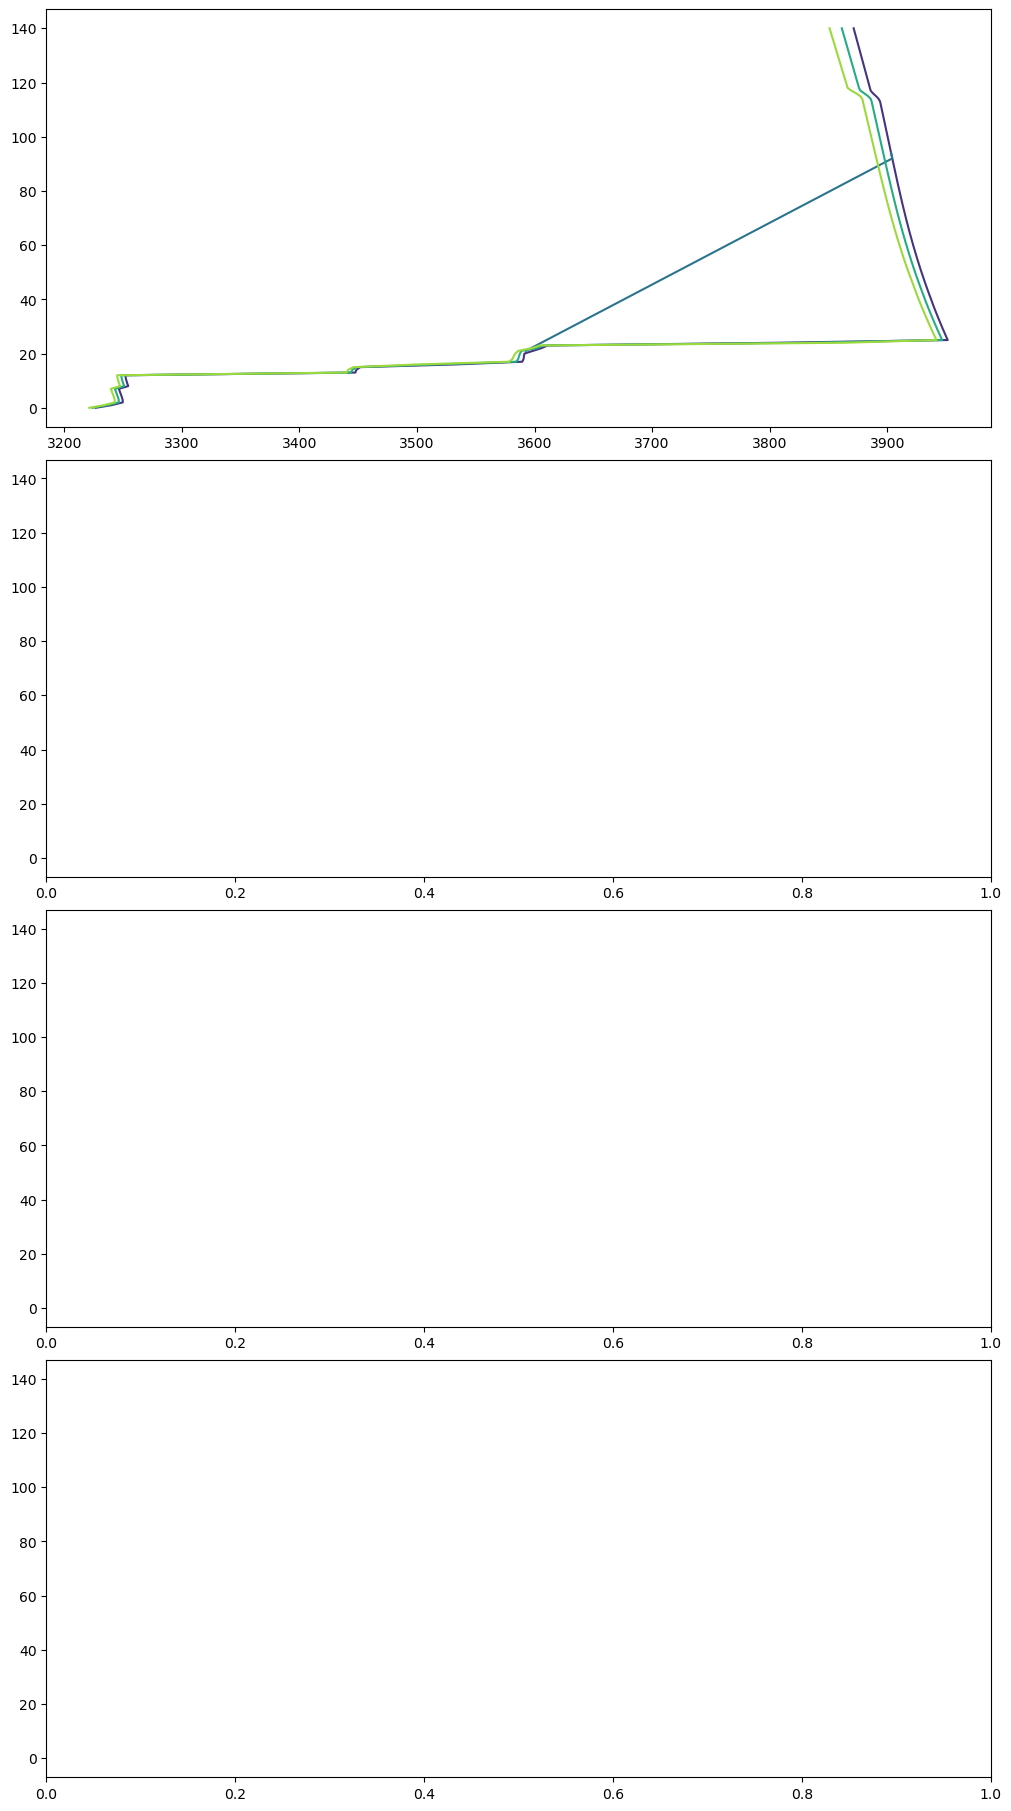

In [28]:
# Plot 5 properties for each composition in a separate 5x1 figure.
# Each composition has 29 isentropes sampled over 141 pressure points from 0 to 140 GPa.
# We select 4 evenly spaced isentropes per composition and plot property (x-axis)
# versus pressure (inverted y-axis).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'sim_tables' not in globals():
    raise RuntimeError('Cell 2 must be run first so sim_tables is available.')

composition_order = ['DMM_PS', 'harzburgite_PS']
composition_titles = {
    'DMM_PS': 'DMM',
    'harzburgite_PS': 'Harzburgite',
}

property_specs = [
    ('rho(g/cm^3)', ['rho(g/cm^3)', 'density']),
    ('Vp', ['Vp', 'VP(km/s)', 'vp']),
    ('Vs', ['Vs', 'VS(km/s)', 'vs']),
    ('VB(km/s)', ['VB(km/s)', 'bulk_velocity']),
]

property_names = ['density', 'p_wave_velocity', 's_wave_velocity', 'temperature']


for sim_name in composition_order:
    if sim_name not in sim_tables:
        raise KeyError(f'Missing table for {sim_name}')

    df = sim_tables[sim_name].copy().reset_index(drop=True)

    
GT_grid = {}

for name, comp in compositions.items(): 
    df = sim_tables[name]
    headers = []
    print(f"\n{name} composition: {comp}")
    comp_array = comp_tables[name]
        
    PT = np.concatenate([df['P(GPa)'].to_numpy().reshape(-1, 1), df['T(K)'].to_numpy().reshape(-1, 1)], axis=1)

    
    attributes = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(
        torch.tensor(comp_array),
        torch.tensor(PT),
        property_names = ['entropy_by_mass', 'density', 'p_wave_velocity', 's_wave_velocity', 'isentropic_bulk_modulus_reuss'])
    
    attributes['temperature'] = torch.tensor(df['T(K)'])
    attributes['pressure'] = torch.tensor(df['P(GPa)'])
    attributes['entropy'] = torch.tensor(df['S(J/g/K)'])
    GT_grid[name] = attributes


    
    n_pressure_points = int(pd.to_numeric(df['P(GPa)'], errors='coerce').nunique(dropna=True))
    if n_pressure_points <= 1 or len(df) % n_pressure_points != 0:
        raise ValueError(
            f'Could not infer isentrope block size for {sim_name}: '
            f'len(df)={len(df)}, unique pressures={n_pressure_points}'
        )

    n_isentropes = len(df) // n_pressure_points
    selected_isentropes = np.linspace(0, n_isentropes - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))

    fig, axes = plt.subplots(
        nrows=len(property_specs),
        ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    plotted_isentropes = []

    for row_idx, property_name in enumerate(property_names):
        ax = axes[row_idx]

        for iso_idx, entropy in enumerate(df['S(J/g/K)'].unique()):
            isentrope_idx = torch.where(torch.tensor(attributes['entropy']) == entropy)[0]
            #plotted_isentropes.append(attributes['entropy'][isentrope_idx])
           

            ax.plot(
                attributes[property_name][isentrope_idx],
                attributes['pressure'][isentrope_idx],
                color=line_colors[iso_idx],
                #linewidth=2.0,
                label=f'S ~ {entropy:.4g}',
            )

        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(f"ML EOS tabulated GT {sim_name}{property_name}")
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')

    plt.title(f'{sim_name} Composition')
    plt.show()


In [27]:
attributes

{'entropy_by_mass': array([2184.10935427, 2195.18717319, 2205.48607489, ..., 3348.21136957,
        3350.32556935, 3352.42735282]),
 'density': array([3226.70466266, 3240.41812368, 3249.72779681, ..., 4147.1477519 ,
        4147.23523106, 4147.32257677]),
 'p_wave_velocity': array([7718.84216088, 7715.20120247, 7712.97581768, ..., 9611.96672868,
        9610.63505417, 9609.30873223]),
 's_wave_velocity': array([4505.09666348, 4509.97341619, 4503.28365674, ..., 5584.93346047,
        5583.92140949, 5582.91323743]),
 'isentropic_bulk_modulus_reuss': array([1.04930273e+11, 1.05004181e+11, 1.05455544e+11, ...,
        2.10680340e+11, 2.10641126e+11, 2.10602094e+11]),
 'temperature': 0       1217.041138
 1       1227.050171
 2       1238.662720
 3       1249.164429
 4       1258.984741
            ...     
 4084    3570.368896
 4085    3615.976562
 4086    3622.493896
 4087    3628.985840
 4088    3635.453857
 Name: T(K), Length: 4089, dtype: float32,
 'pressure': 0         0.0
 1         1

In [ ]:
from ..src.nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

INDEX_TO_PHASE = {
    1:'plg', 2:'sp', 3:'opx', 4:'c2c', 5:'cpx', 6:'wo', 7:'pwo', 8:'gt', 9:'cpv',
    10:'ol', 11:'wa', 12:'ri', 13:'il', 14:'pv', 15:'ppv', 16:'cf', 17:'nal', 18:'mw',
    19:'qtz', 20:'coes', 21:'st', 22:'apbo', 23:'ky', 24:'neph', 25:'fea', 26:'feg', 27:'fee'
}

PHASE_TO_INDEX = {v: k for k, v in INDEX_TO_PHASE.items()}

phase_names = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases
mass_phasedict = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.mass_phasedict


IP_PYROLITE = [19,20,21,22,10,11,12,18,14,15,13,8,16,9,3,4,5,1,2,23,24,17,25,26,27,6,7] # Convention of HeFESTo creators. Table comp names

phase_order = []

for i, idx in enumerate(IP_PYROLITE):
    print(f"{i}: {INDEX_TO_PHASE[idx]}")
    shortname = INDEX_TO_PHASE[idx]
    if shortname in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values():
        phase_order.append(np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys()))[np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())) == shortname][0])

# Now stack phase abundances in this order (bottom to top) using the following script! Use the matplotlib.animation.FuncAnimation function to animate  

# -------------------------------------------------------
# Phase color rules (named colors, grouped by mineral family)
# -------------------------------------------------------
def phase_colors():
    col = {}

    # Silica polymorphs
    for p in ['qtz', 'coes', 'st', 'apbo', 'cacl']:
        col[p] = 'dimgray'

    # Plagioclase / feldspars (light)
    for p in ['plg', 'pwo', 'wo', 'neph']:
        col[p] = 'lightgray'

    # Aluminum silicates & Al-bearing (distinct from general silica)
    for p in ['ky', 'nal']:
        col[p] = 'mediumpurple'

    # Pyroxenes
    for p in ['opx', 'cpx', 'c2c']:
        col[p] = 'steelblue'

    # Spinel
    col['sp'] = 'brown'

    # Garnet
    col['gt'] = 'red'

    # Olivine + high-P polymorphs
    for p in ['ol', 'wa', 'ri', 'il']:
        col[p] = 'forestgreen'

    # Perovskite family (varying yellow/beige)
    col['pv']  = 'khaki'
    col['ppv'] = 'goldenrod'
    col['cf']  = 'wheat'
    col['cpv'] = 'tan'

    # Iron phases (native iron/allotropes)
    for p in ['fea', 'feg', 'fee']:
        col[p] = 'sienna'

    # Ferropericlase / magnesiowüstite (if present)
    col['mw'] = 'magenta'

    # Fallback for anything unexpected
    return col

# -----------------------------------
# Phase stack (please remove vs overlay, instead have two subplots of stacked sim_table and emulation phase masses)
# -----------------------------------
def plot_phase_stack_with_vs(df66, df56, comp, T):
    depth = df66['Depth'].values
    # Grab phases present in df66 (exclude P, Depth, T)
    ignore = set(['Pi','P','Ti','T','Depth'])
    # Order per composition, but keep only columns that exist
    order = phase_order # alias
    emulator_phase_cols = [mass_phasedict[p] for p in order]
    colors = phase_colors()

    # Build stacked plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bottoms = np.zeros_like(depth, dtype=float)
    for name in order:
        vals = df66[name].values
        top = bottoms + vals
        ax.fill_between(depth, bottoms, top,
                        facecolor=colors.get(name, '#aaaaaa'),
                        edgecolor='k', linewidth=1.6)
        # Label at max thickness if significant
        if np.nanmax(vals) > 0.03:
            i_max = int(np.nanargmax(vals))
            band = vals > (0.35 * vals[i_max])   # "significant" around max (tweak factor if needed)
            if band.any():
                # X center: depth weighted by phase thickness
                x_c = np.average(depth[band], weights=vals[band])
                # Y center: midpoint of the stacked band, also weighted by phase thickness
                y_mid_band = 0.5 * (bottoms[band] + top[band])
                y_c = np.average(y_mid_band, weights=vals[band])

                # Clean label (no bbox), centered in the phase
                ax.text(x_c, y_c, name,
                        ha='center', va='center', fontsize=8, clip_on=True)
        bottoms = top

    # Overlay Vs on right Y-axis; X is Depth
    vs_depth = df56['Depth'].values
    vs_values = df56['VS(km/s)'].values
    ax2 = ax.twinx()
    ax2.plot(vs_depth, vs_values, color='blue', linewidth=2, label='Vs (km/s)')
    ax2.set_ylabel('Vs (km/s)', color='red')
    ax2.tick_params(axis='y', labelcolor='black')

    ax.set_xlim(depth.min(), depth.max())
    ax.set_ylim(0, 1.0)
    ax.set_xlabel('Depth (km)')
    ax.set_ylabel('Phase fraction (atomic)')
    ax.set_title(f'Phase proportions — {comp.upper()}, T={T} K')
    fig.tight_layout()
    return fig, ax

S(J/g/K)


2.2

In [8]:
import importlib
import src.nMELTS.engine.API as api
importlib.reload(api)

[INFO] Looking for HeFESTo model at: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer with value: 0.0
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPS.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer 

<module 'src.nMELTS.engine.API' from 'c:\\Git_Repositories\\nMELTS\\src\\nMELTS\\engine\\API.py'>


harzburgite_PS composition: {'Si': 3.57887, 'Mg': 5.64233, 'Fe': 0.58052, 'Ca': 0.07969, 'Al': 0.0974, 'Na': 0.0016, 'Cr': 0.0196, 'O': 13.63947}
[[3.578870e+00 5.642330e+00 5.805200e-01 7.969000e-02 9.740000e-02
  1.600000e-03 1.960000e-02 1.363947e+01]]
[[2.200000e+00 3.578870e+00 5.642330e+00 5.805200e-01 7.969000e-02
  9.740000e-02 1.600000e-03 1.960000e-02 1.363947e+01]
 [2.425000e+00 3.578870e+00 5.642330e+00 5.805200e-01 7.969000e-02
  9.740000e-02 1.600000e-03 1.960000e-02 1.363947e+01]
 [2.650000e+00 3.578870e+00 5.642330e+00 5.805200e-01 7.969000e-02
  9.740000e-02 1.600000e-03 1.960000e-02 1.363947e+01]
 [2.900000e+00 3.578870e+00 5.642330e+00 5.805200e-01 7.969000e-02
  9.740000e-02 1.600000e-03 1.960000e-02 1.363947e+01]]
Input grid shape: (564, 10)
Adding ferric column...
[INFO] Adding 'chem_out' to outputs for temperature calculation.
[INFO] Adding 'phase_moles' to outputs for temperature calculation.
Phase forcing did not satisfy mass balance even after 3 iterations
te

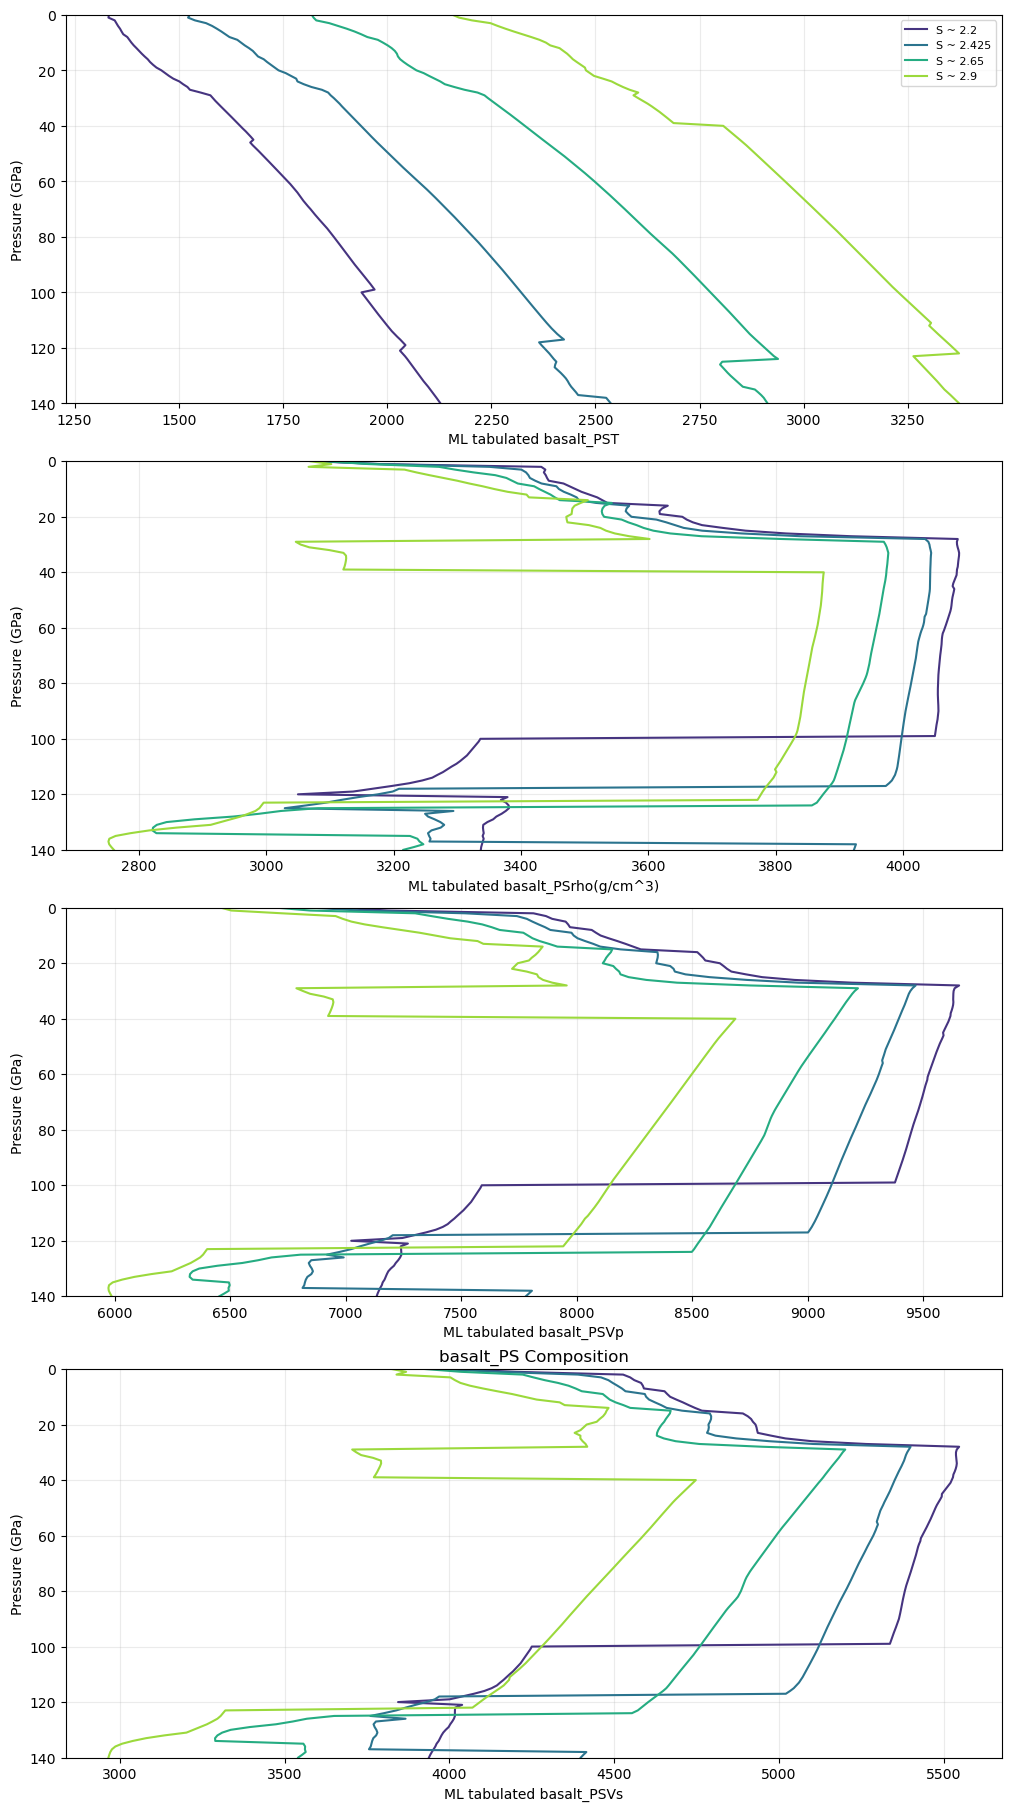

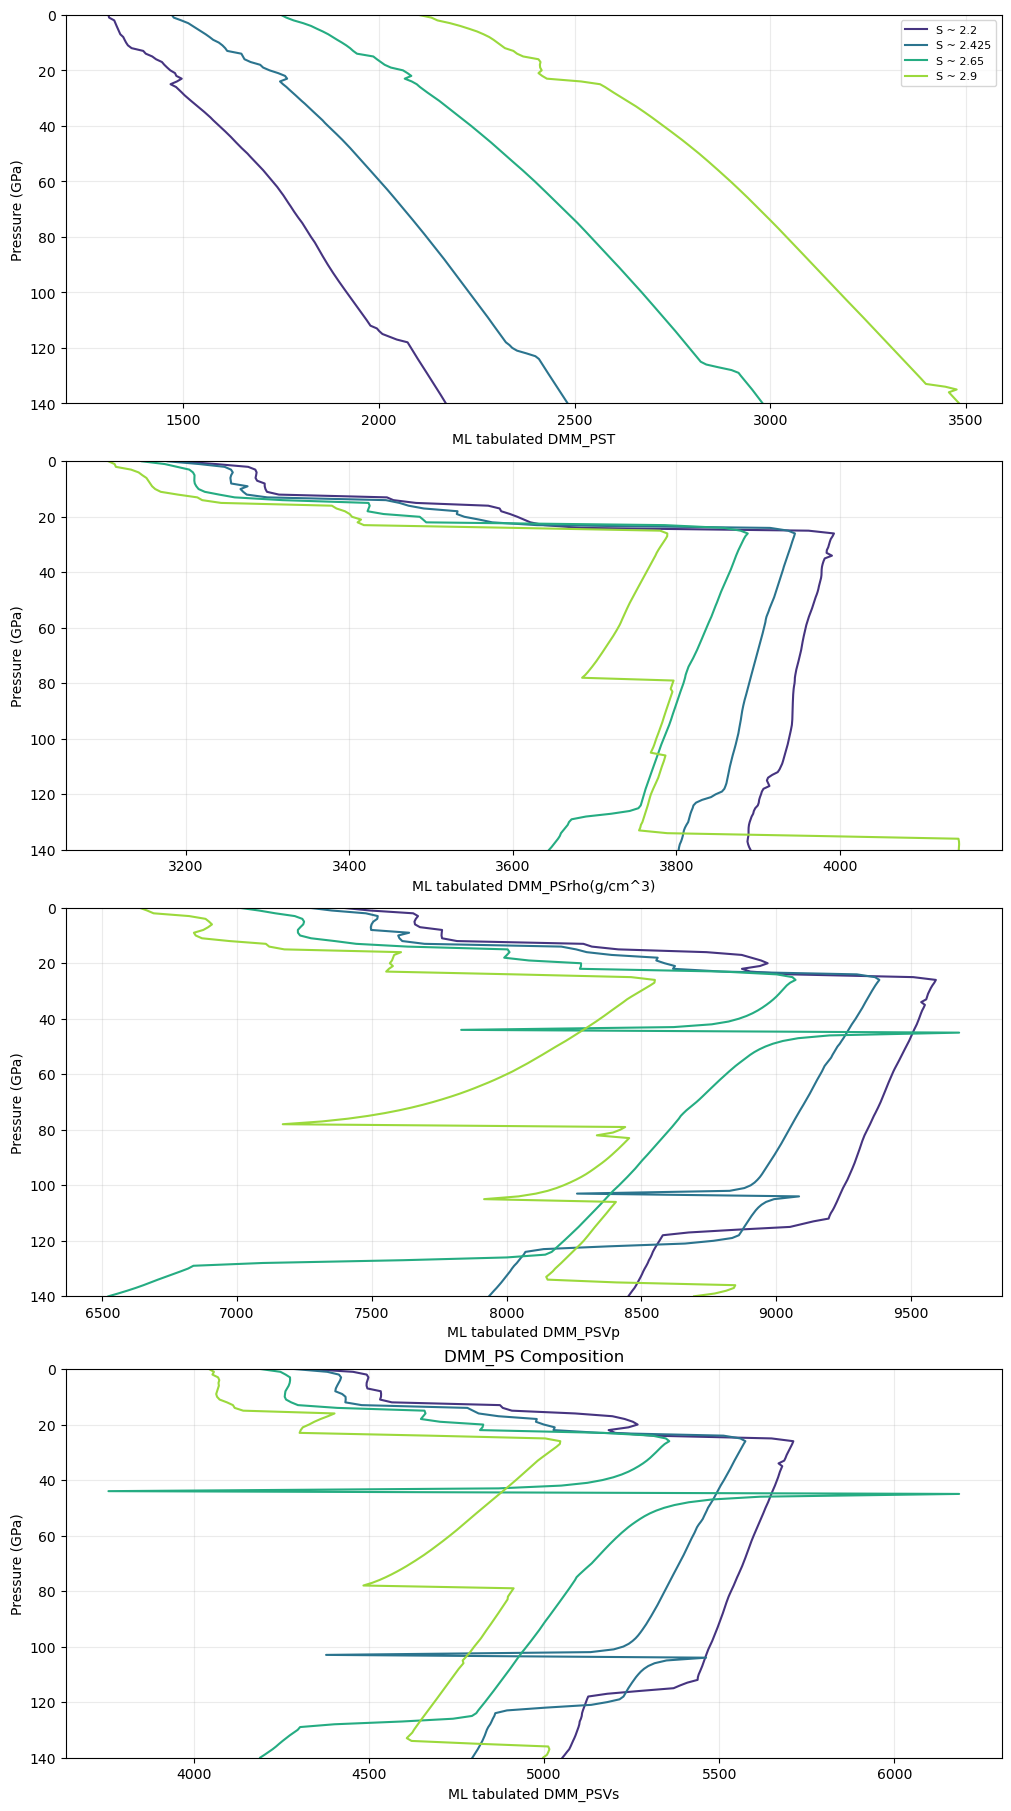

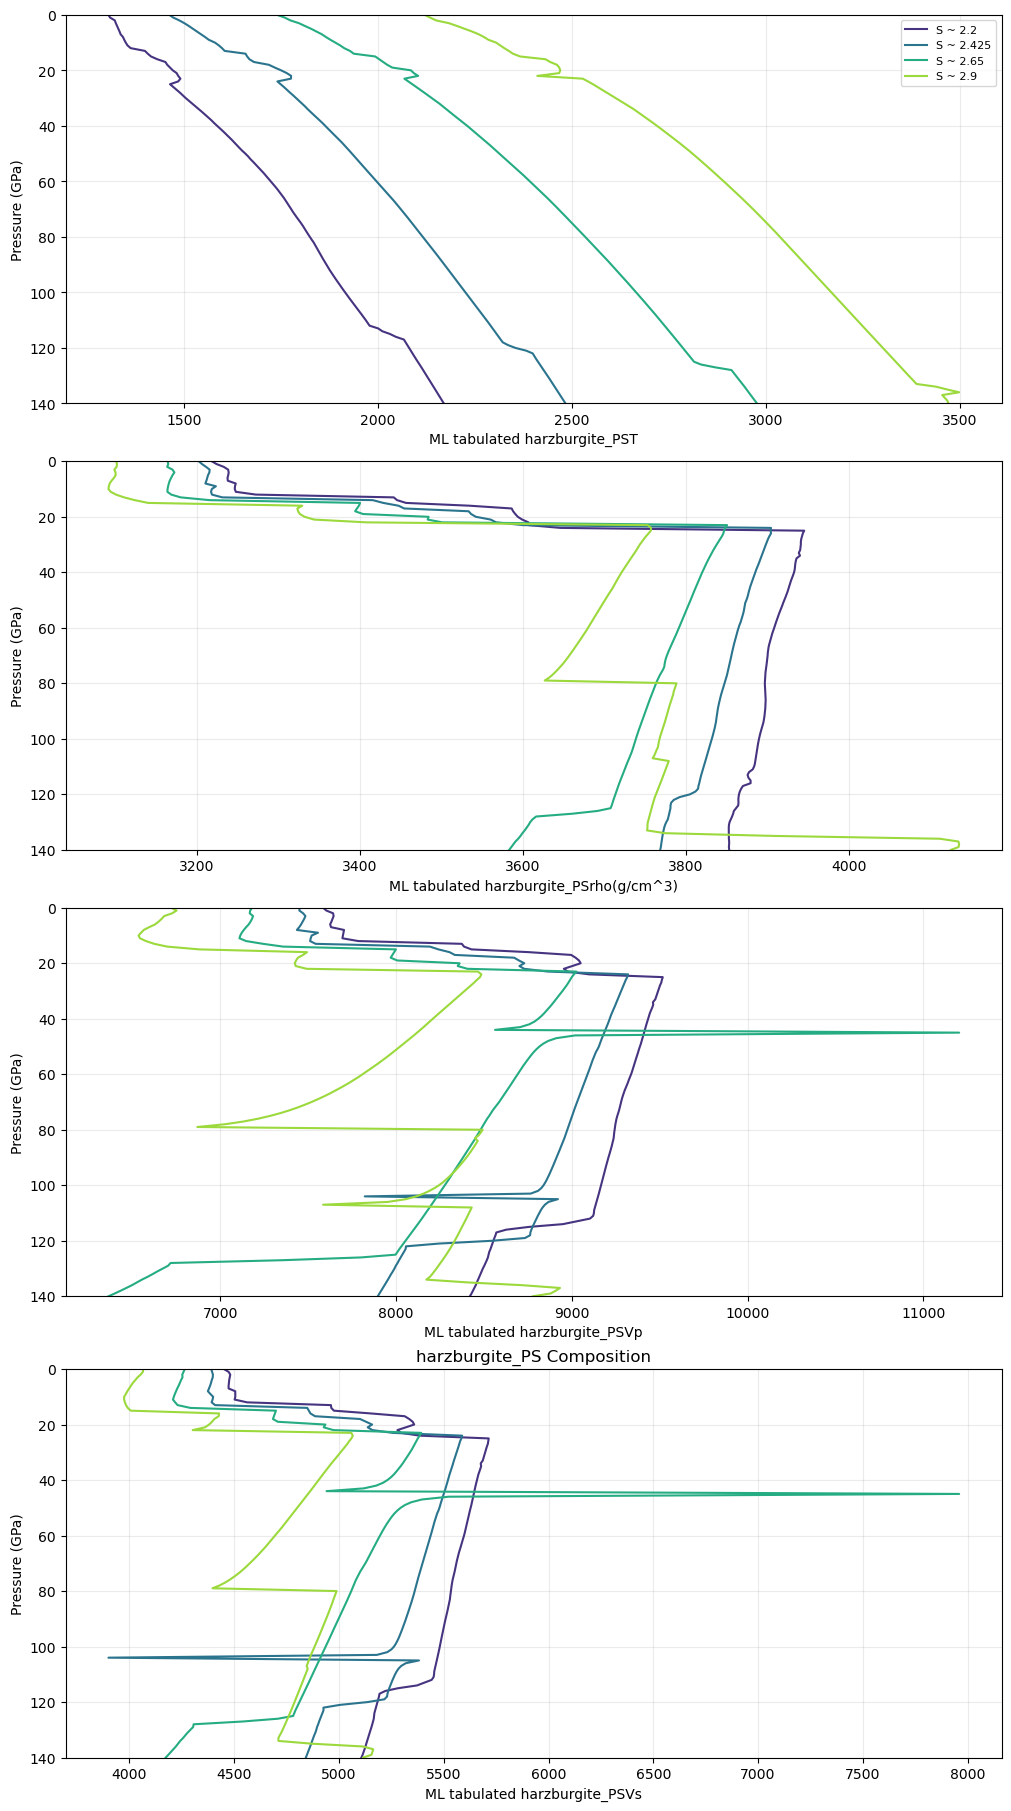

In [ ]:
import torch


#compositions = {'basalt_PS': basalt, 'DMM_PS': DMM, 'harzburgite_PS': harzburgite}

pressures = np.linspace(0.0, 140.0, 141).astype(np.float32)  # GPa grid used for emulator adiabats
entropies = np.unique(plotted_isentropes)  # J/g/K grid for isentropes

ML_grid = {}

for name, comp in compositions.items(): 
    headers = []
    print(f"\n{name} composition: {comp}")
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = grid_sample_explicit([pressures[:,np.newaxis], entropies[:,np.newaxis]], comp_array)
    print(f"Input grid shape: {input_grid.shape}")

    headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', ] + headers
    #features_tensor = HeFESToEmulatorCPU.parse_input(input_grid, headers=headers)
    result = HeFESToEmulatorCPU.ForwardNN(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'temperature']
    )
    print(result['temperature'])
    PT = torch.concatenate([torch.tensor(input_grid[:, 0]).unsqueeze(1), result['temperature'].unsqueeze(1)], dim=1)
    attributes = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(
        result['component_moles'],
        PT,
        property_names = ['entropy_by_mass', 'density', 'p_wave_velocity', 's_wave_velocity', 'isentropic_bulk_modulus_reuss'])
    
    attributes['temperature'] = result['temperature']
    attributes['pressure'] = input_grid[:, 0]
    attributes['entropy'] = input_grid[:, 1]
    ML_grid[name] = attributes


composition_order = ['basalt_PS', 'DMM_PS', 'harzburgite_PS']


property_specs = {
    ('rho(g/cm^3)', 'density'),
    ('Vp', 'p_wave_velocity'),
    ('Vs', 's_wave_velocity'),
    ('T', 'temperature')
}



for sim_name in composition_order:


    attribute_dict = ML_grid.get(sim_name)


    fig, axes = plt.subplots(
            nrows=len(property_specs),
            ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    plotted_isentropes = []

    for row_idx, (property_name, candidates) in enumerate(property_specs):
        ax = axes[row_idx]
        

        for iso_idx, entropy in enumerate(entropies):
            isentrope_idx = torch.where(torch.tensor(attribute_dict['entropy']) == entropy)[0]
            plotted_isentropes.append(attribute_dict['entropy'][isentrope_idx])
           

            ax.plot(
                attribute_dict[candidates][isentrope_idx],
                attribute_dict['pressure'][isentrope_idx],
                color=line_colors[iso_idx],
                #linewidth=2.0,
                label=f'S ~ {entropy:.4g}',
            )

        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(f"ML tabulated {sim_name}{property_name}")
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')

    plt.title(f'{sim_name} Composition')
    plt.show()
    

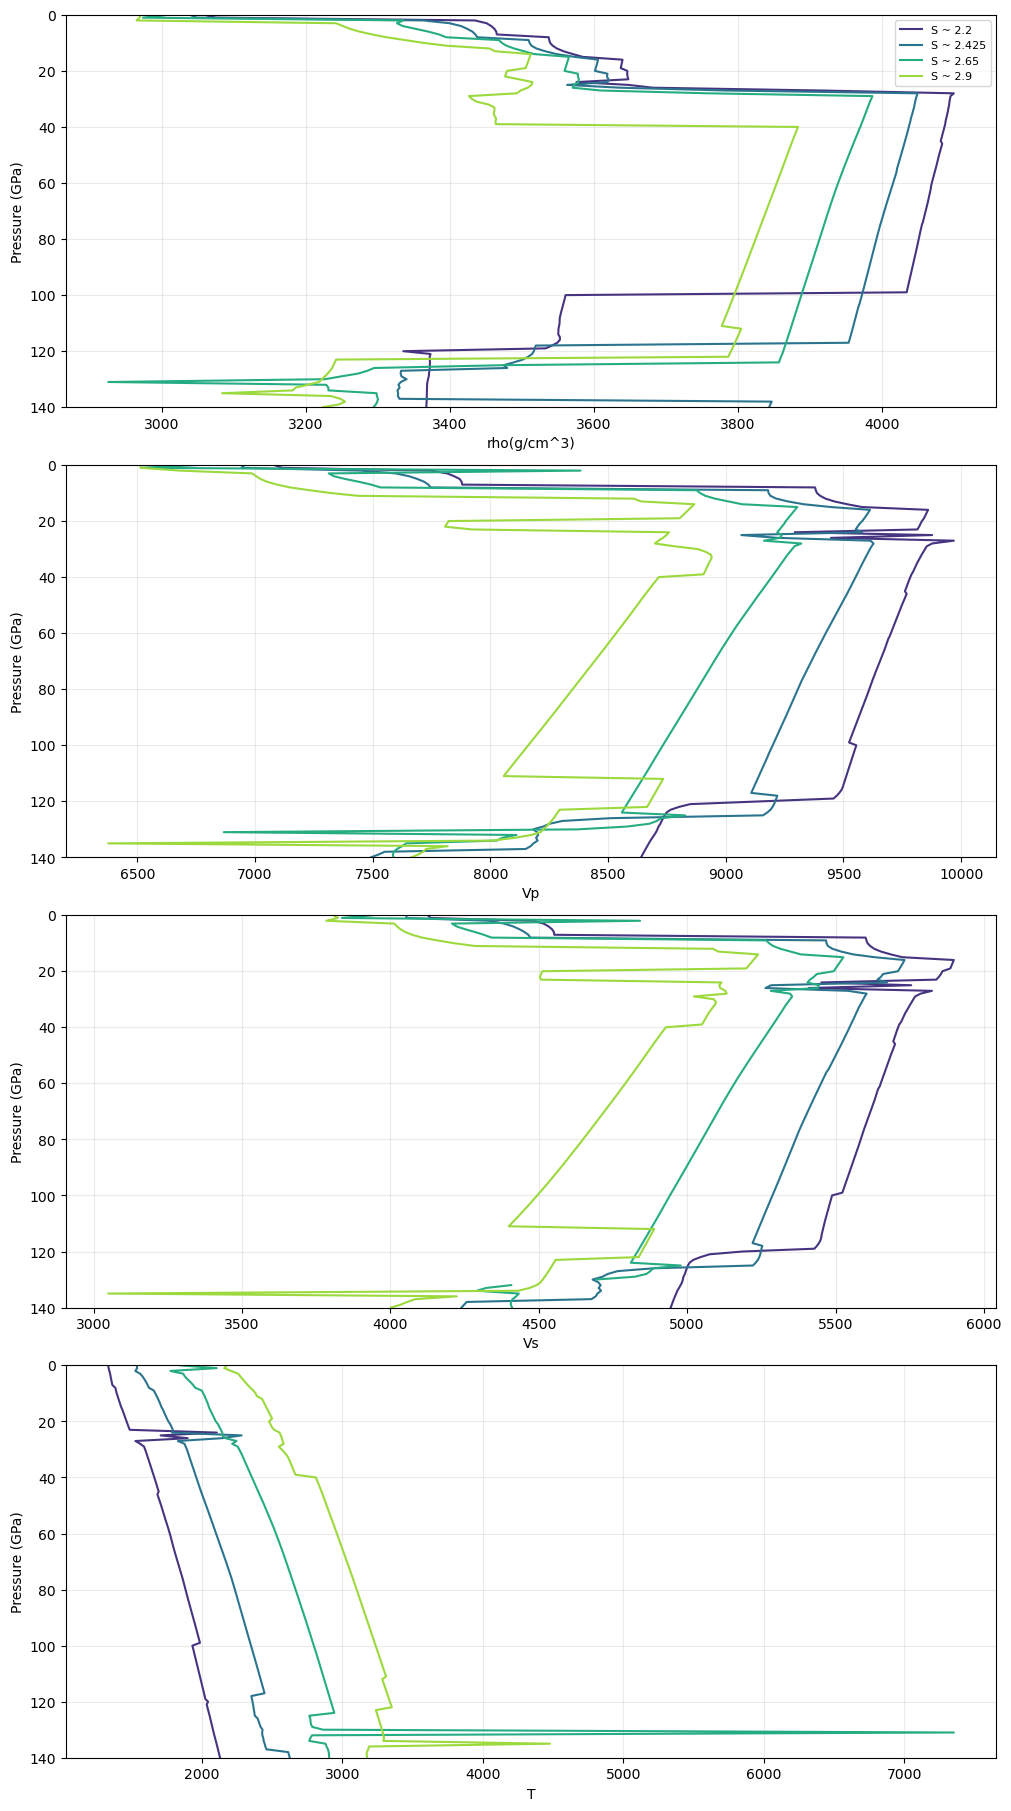

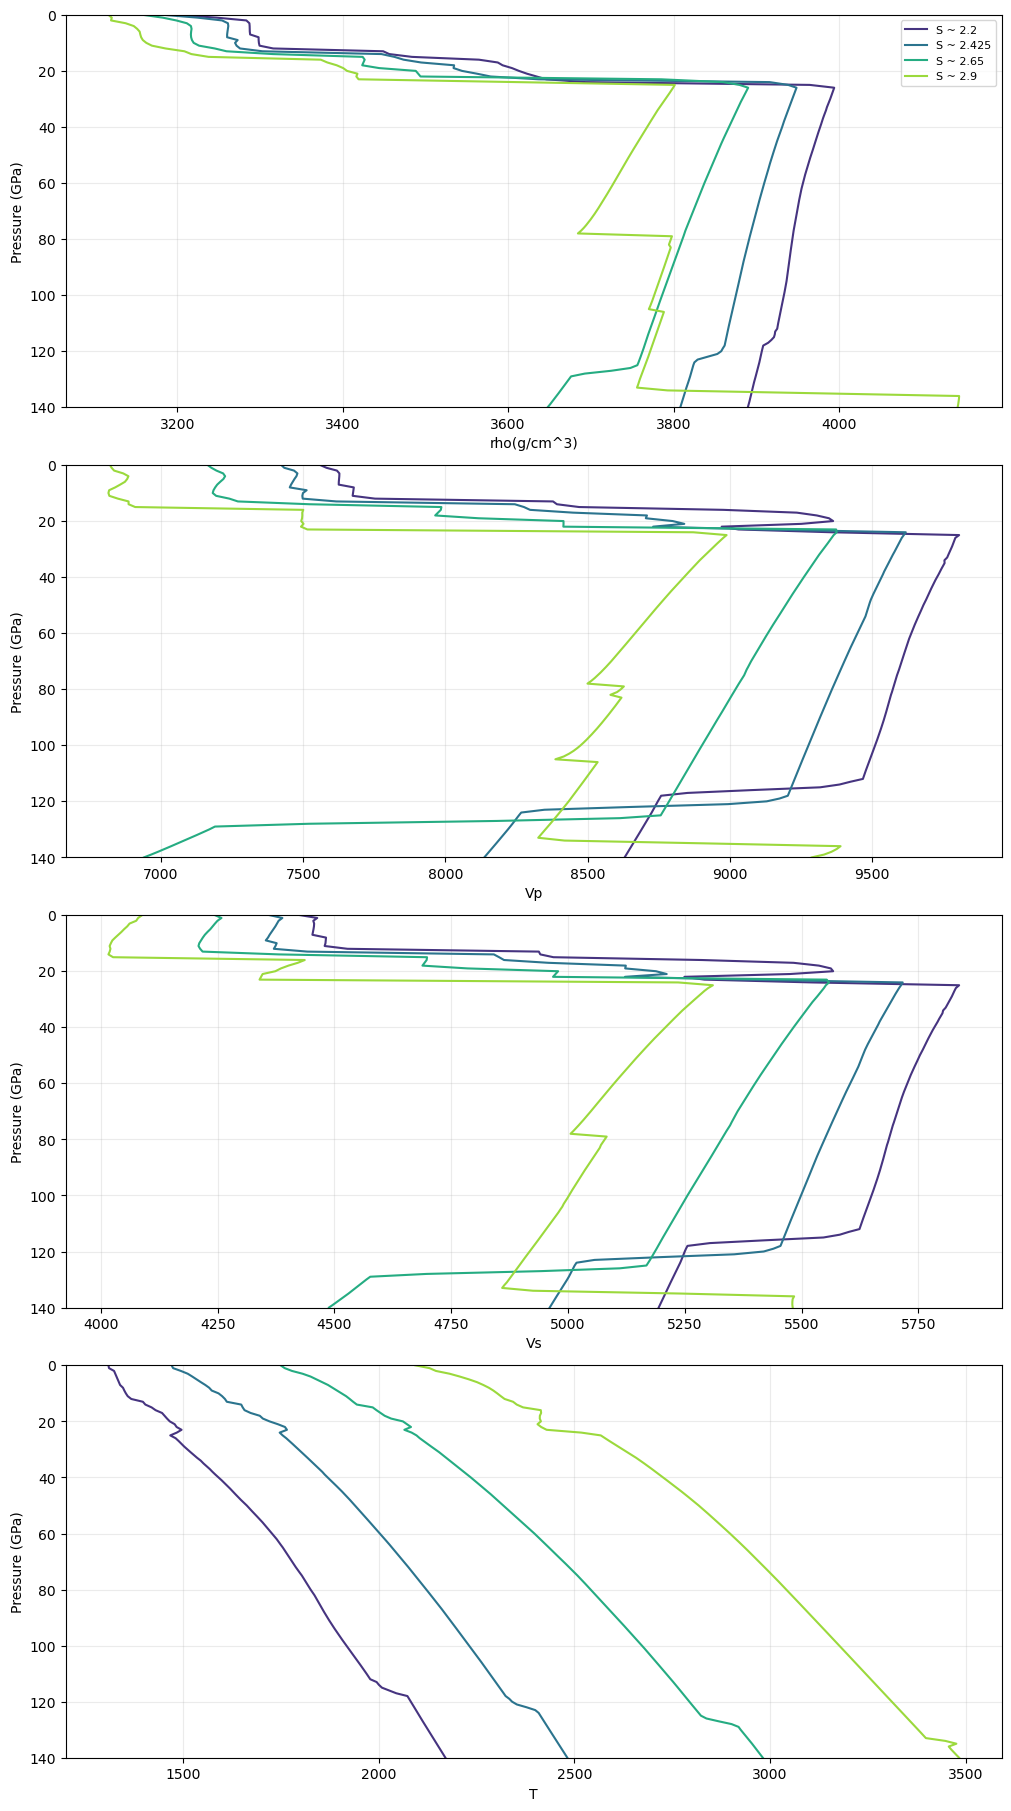

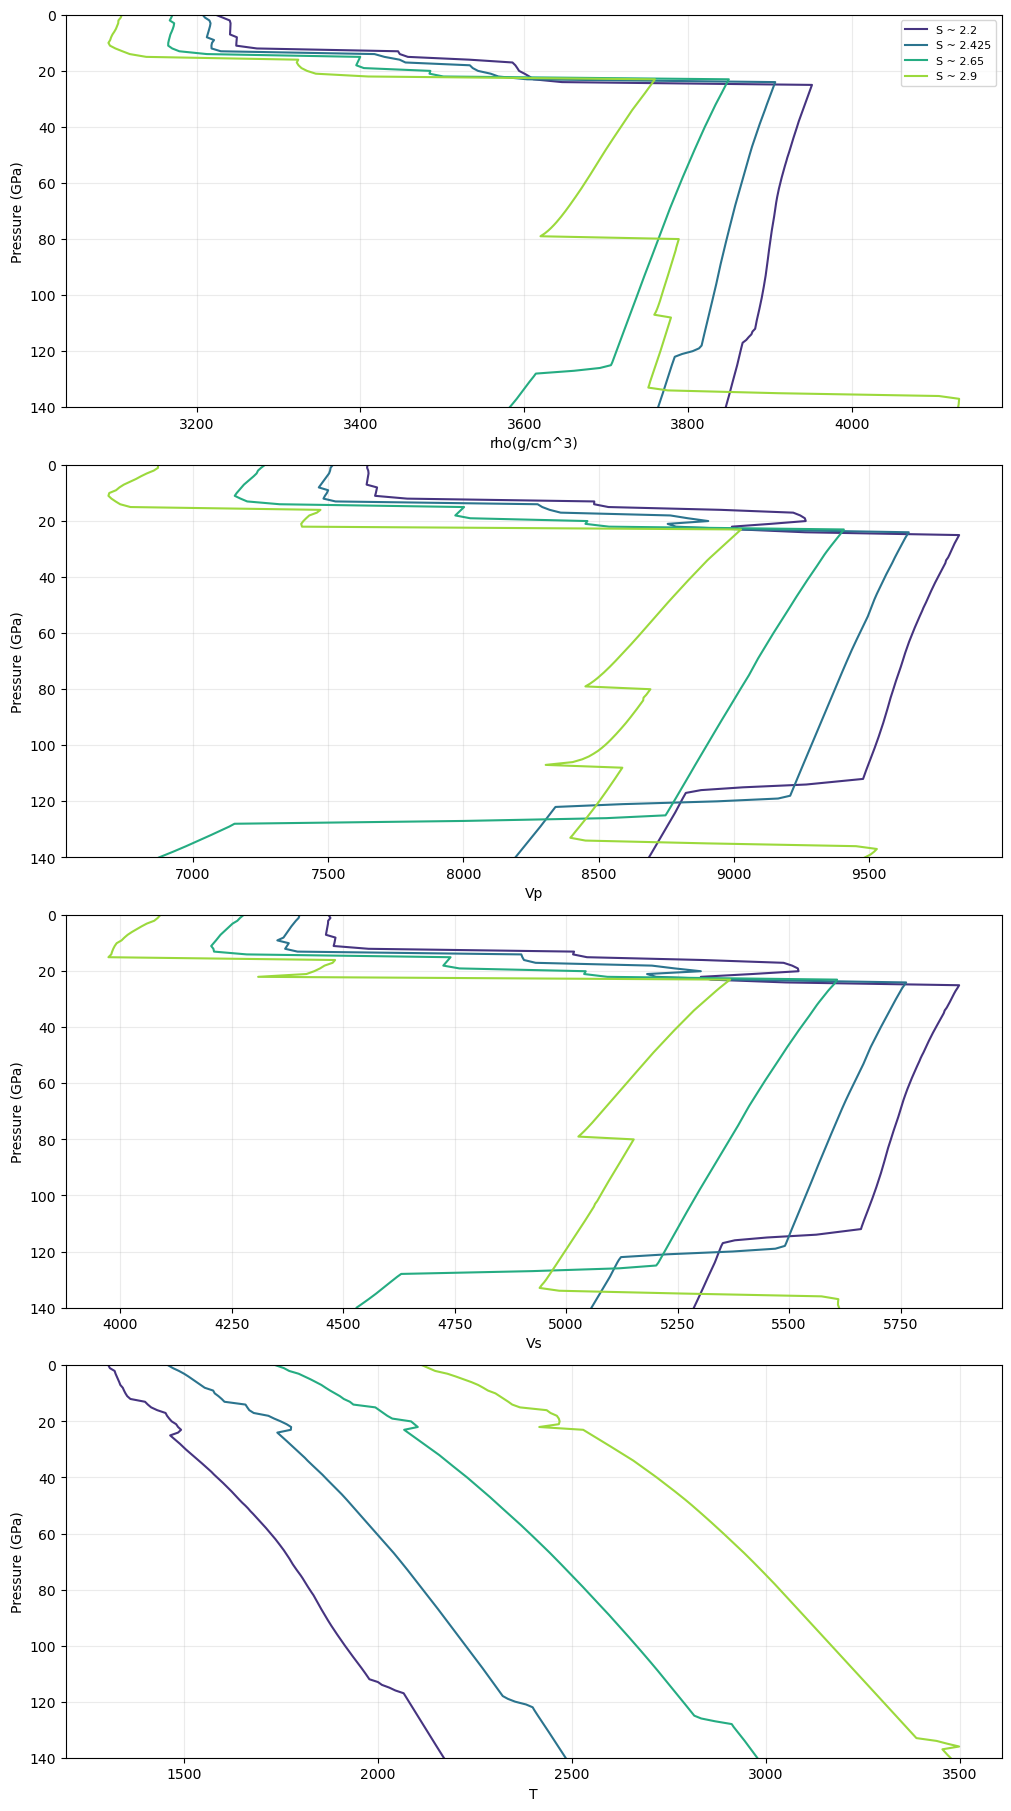

In [18]:
isentrope_idx

3

In [ ]:
import burnman
from src.nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

mineral_list = dir(burnman.minerals.SLB_2024)

shorthands = list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())
longhands = list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys())

compnames = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_names

BurnMan_minerals = dir(burnman.minerals.SLB_2024)

mineral= np.array()
for mineral, idx in HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_indices.items():
    print(f"Emulator {mineral}: {compnames[idx]}")
    MinComps = compnames[idx]
    try:
        BurnMan_mineral = getattr(burnman.minerals.SLB_2024, mineral)()
        print(f"{mineral} present in BurnMan!")
        subcomps = getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae
        for sc in MinComps:
            contains = sc in 
            print(f"  - {sc}")


    for mineral in mineral_list:
        print(mineral)
        try:
            endmember_names = getattr(burnman.minerals.SLB_2022, mineral)().endmember_names
            for i, name in enumerate(endmember_names):
                print(f"{endmember_names[i]}: {getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae[i]}")
        except:
            try:        
                print(f"Formula: {getattr(burnman.minerals.SLB_2024, mineral)().formula}")
                print(f"Pure Phase!")
            except:
                print(f"{mineral} is not a material!")
        print("\n\n###############################\n")


plagioclase: ['anorthite' 'albite']
spinel: ['spinel' 'hercynite' 'magnetite' 'picro-chromite']
olivine: ['forsterite' 'fayalite']
wadsleyite: ['mg-wadsleyite' 'fe-wadsleyite']
ringwoodite: ['mg-ringwoodite' 'fe-ringwoodite']
orthopyroxene: ['enstatite' 'ferrosilite' 'mg-tschermaks' 'ortho-diopside']
clinopyroxene: ['diopside' 'hedenbergite' 'clinoenstatite' 'ca-tschermaks' 'jadeite'
 'acmite']
hp-clinopyroxene: ['hp-clinoenstatite' 'hp-clinoferrosilite']
ca-perovskite: ['ca-perovskite']
akimotoite: ['mg-akimotoite' 'fe-akimotoite' 'corundum' 'hematite' 'eskolaite']
garnet: ['pyrope' 'almandine' 'grossular' 'mg-majorite' 'na-majorite' 'andradite'
 'knorringite']
stishovite: ['stishovite']
bridgmanite: ['mg-bridgmanite' 'fe-bridgmanite' 'al-bridgmanite' 'ferric-bridgmanite'
 'ferric-bridgmanite-ls' 'ferric-al-bridgmanite' 'cr-bridgmanite']
post-perovskite: ['mg-post-perovskite' 'fe-post-perovskite' 'al-post-perovskite'
 'ferric-post-perovskite' 'cr-post-perovskite']
ferropericlase: ['pe

In [33]:
burnman.minerals.SLB_2022.sp().formula

{'Mg': 4.0, 'Al': 8.0, 'O': 16.0}

In [ ]:
import burnman

mineral_list = dir(burnman.minerals.SLB_2024)

for mineral in mineral_list:
    print(mineral)
    try:
        endmember_names = getattr(burnman.minerals.SLB_2024, mineral)().endmember_names
        for i, name in enumerate(endmember_names):
            print(f"{endmember_names[i]}: {getattr(burnman.minerals.SLB_2024, mineral)().endmember_formulae[i]}")
    except:
        try:        
            print(f"Formula: {getattr(burnman.minerals.SLB_2024, mineral)().formula}")
            print(f"Pure Phase!")
        except:
            print(f"{mineral} is not a material!")
    print("\n\n###############################\n")


{'Ca': 3.0, 'Fe': 2.0, 'Si': 3.0, 'O': 12.0}
{'Ca': 3.0, 'Al': 2.0, 'Si': 3.0, 'O': 12.0}


AsymmetricRegularSolution
AsymmetricRegularSolution is not a material!


###############################

IdealSolution
IdealSolution is not a material!


###############################

Mineral
Mineral is not a material!


###############################

RelaxedSolution
RelaxedSolution is not a material!


###############################

SLB3
SLB3 is not a material!


###############################

SLB3Stishovite
SLB3Stishovite is not a material!


###############################

Solution
Solution is not a material!


###############################

SymmetricRegularSolution
SymmetricRegularSolution is not a material!


###############################

__builtins__
__builtins__ is not a material!


###############################

__cached__
__cached__ is not a material!


###############################

__doc__
__doc__ is not a material!


###############################

__file__
__file__ is not a material!


###############################

__loader__
__loader__ is not a mat

In [19]:
mineral = 'clinopyroxene'
getattr(burnman.minerals.SLB_2024, mineral)().endmember_names


['Diopside',
 'Hedenbergite',
 'Clinoenstatite',
 "Lime_Tschermak'",
 'Jadeite',
 'Acmite']

ImportError: cannot import name 'compute_physub_bulk_matrix' from 'nMELTS.engine.EOS_arithmetic' (c:\Git_Repositories\nMELTS\src\nMELTS\engine\EOS_arithmetic\__init__.py)

In [ ]:
# BurnMan search (fresh cell) - robustly search emulator components in BurnMan
import burnman
from nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

shorthand_map = HEFESTO_ABBREVIATION_TO_SHORT_NAMES
compnames = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_names
label_indices = HeFESToEmulatorCPU.isentropic_emulator.model.ml_indexer.label_indices

def _ensure_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    return [x]

for mineral, idx in label_indices.items():
    print("EMULATOR PHASE:", mineral, f"(index={idx})")
    MinComps = _ensure_list(compnames[idx] if idx < len(compnames) else [])
    print("  Emulator components:", MinComps)

    bm_obj = None
    found_ver = None
    for ver in ("SLB_2024", "SLB_2022"):
        module = getattr(burnman.minerals, ver, None)
        if module and hasattr(module, mineral):
            try:
                bm_obj = getattr(module, mineral)()
                found_ver = ver
                break
            except Exception as e:
                bm_obj = None
    if bm_obj is None:
        print("  -> Not found in burnman SLB_2024/2022")
        print("
#"*30 + "
")
        continue
    print(f"  -> Found in burnman.minerals.{found_ver}")
    em_names = getattr(bm_obj, 'endmember_names', []) or []
    em_forms = getattr(bm_obj, 'endmember_formulae', []) or []
    formula = getattr(bm_obj, 'formula', None)
    if em_names:
        print("    endmember_names:", em_names)
    if em_forms:
        print("    endmember_formulae:", em_forms)
    if formula:
        print("    formula:", formula)

    for comp in MinComps:
        print(f"    Searching for component '{comp}':")
        found_any = False
        candidates = {str(comp)}
        if str(comp) in shorthand_map:
            candidates.add(shorthand_map[str(comp)])
        for k, v in shorthand_map.items():
            if str(comp) == v:
                candidates.add(k)
        for cand in list(candidates):
            cand = str(cand)
            if any(cand == str(n) or cand in str(n) for n in em_names):
                print(f"      - matched endmember name: {cand}")
                found_any = True
            if any(cand == str(f) or cand in str(f) for f in em_forms):
                print(f"      - matched endmember formula: {cand}")
                found_any = True
            if formula and cand in str(formula):
                print(f"      - matched phase formula: {cand}")
                found_any = True
        if not found_any:
            print("      - No match in this burnman phase")
    print("
#"*30 + "
")


In [12]:
# Plot emulator outputs with same layout as cell 3
# Shows isentropes from emulator API predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'sim_tables' not in globals():
    raise RuntimeError('Cell 2 must be run first so sim_tables is available.')

# Define compositions
compositions = {
    'basalt_PS': basalt,
    'DMM_PS': DMM,
    'harzburgite_PS': harzburgite,
}

composition_titles = {
    'basalt_PS': 'Basalt',
    'DMM_PS': 'DMM',
    'harzburgite_PS': 'Harzburgite',
}

property_specs = [
    ('rho(g/cm^3)', 'density'),
    ('Vp', 'p_wave_velocity'),
    ('Vs', 's_wave_velocity'),
    ('VB(km/s)', 'K_S'),
]

pressures = np.linspace(0.0, 140.0, 141).astype(np.float32)
entropies = np.unique(plotted_isentropes)  # from cell 4

# Generate emulator predictions for all compositions
emulator_results = {}

for sim_name, comp in compositions.items():
    print(f"Generating emulator predictions for {sim_name}...")
    
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    headers = []
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
    
    input_grid = grid_sample_explicit([entropies[:, np.newaxis], pressures[:, np.newaxis]], comp_array)
    headers = ['S(J/g/K)(System_main)', 'P(GPa)(System_main)'] + headers
    
    result = HeFESToEmulatorCPU.ForwardMB(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'temperature']
    )
    
    PT = np.concatenate([
        input_grid[:, 0:1].cpu().numpy(),
        result['temperature'].cpu().numpy()
    ], axis=1)
    
    attributes = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(
        result['component_moles'],
        PT,
        property_names=['entropy_by_mass', 'density', 'p_wave_velocity', 
                        's_wave_velocity', 'K_S']
    )
    
    # Store results: reshape to (n_isentropes, n_pressures, n_properties)
    n_entropy = len(entropies)
    n_pressure = len(pressures)
    
    for key in attributes:
        if isinstance(attributes[key], torch.Tensor):
            attributes[key] = attributes[key].detach().cpu().numpy()
    
    emulator_results[sim_name] = {
        'pressures': pressures,
        'entropies': entropies,
        'attributes': attributes,
        'input_grid': input_grid.cpu().numpy(),
    }

# Plot emulator outputs
for sim_name in ['basalt_PS', 'DMM_PS', 'harzburgite_PS']:
    data = emulator_results[sim_name]
    pressures = data['pressures']
    entropies = data['entropies']
    attributes = data['attributes']
    input_grid = data['input_grid']
    
    n_entropy = len(entropies)
    n_pressure = len(pressures)
    selected_isentropes = np.linspace(0, n_entropy - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))
    
    fig, axes = plt.subplots(
        nrows=len(property_specs),
        ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    
    for row_idx, (plot_name, attr_name) in enumerate(property_specs):
        ax = axes[row_idx]
        prop_values = attributes[attr_name]  # shape (n_entropy * n_pressure,)
        
        for iso_idx, isentrope_idx in enumerate(selected_isentropes):
            start = isentrope_idx * n_pressure
            end = start + n_pressure
            
            x_data = prop_values[start:end]
            y_data = pressures
            entropy_value = float(entropies[isentrope_idx])
            
            ax.plot(
                x_data,
                y_data,
                color=line_colors[iso_idx],
                linewidth=2.0,
                label=f'S ~ {entropy_value:.4g}',
            )
        
        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(plot_name)
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')
    
    fig.suptitle(
        f"HeFESTo PS (Emulator): {composition_titles.get(sim_name, sim_name)} | "
        f"4 Evenly Spaced Isentropes",
        fontsize=16,
    )
    plt.show()

print("Emulator plotting complete!")


Generating emulator predictions for basalt_PS...
[[4.611160e+00 1.331970e+00 6.170100e-01 1.228550e+00 1.810900e+00
  3.953300e-01 5.080000e-03 1.535841e+01]]
[[0.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [2.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 ...
 [1.380000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.390000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.400000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]]
Adding ferric column...
[INFO] Adding 'chem_out' to outputs for temperature calculation.
[INFO] Adding 'phase_moles' to outputs for temperature calculation.
Unexplained oxide: Al2O3 in 106 samples of 564.
Unexplained oxide: CaO in 106 samples of 564.
Unexplained oxide: Cr2O3 in 106 samples of 564.
Unexplained ox

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [13]:
# Plot emulator outputs with same layout as cell 3
# Shows isentropes from emulator API predictions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'sim_tables' not in globals():
    raise RuntimeError('Cell 2 must be run first so sim_tables is available.')

# Define compositions
compositions = {
    'basalt_PS': basalt,
    'DMM_PS': DMM,
    'harzburgite_PS': harzburgite,
}

composition_titles = {
    'basalt_PS': 'Basalt',
    'DMM_PS': 'DMM',
    'harzburgite_PS': 'Harzburgite',
}

property_specs = [
    ('rho(g/cm^3)', 'density'),
    ('Vp', 'p_wave_velocity'),
    ('Vs', 's_wave_velocity'),
    ('VB(km/s)', 'K_S'),
]

pressures = np.linspace(0.0, 140.0, 141).astype(np.float32)
entropies = np.unique(plotted_isentropes)  # from cell 4

# Generate emulator predictions for all compositions
emulator_results = {}

for sim_name, comp in compositions.items():
    print(f"Generating emulator predictions for {sim_name}...")
    
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    headers = []
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
    
    input_grid = grid_sample_explicit([entropies[:, np.newaxis], pressures[:, np.newaxis]], comp_array)
    headers = ['S(J/g/K)(System_main)', 'P(GPa)(System_main)'] + headers
    
    result = HeFESToEmulatorCPU.ForwardMB(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'temperature']
    )
    
    PT = np.concatenate([
        input_grid[:, 0:1].cpu().numpy(),
        result['temperature'].cpu().numpy()
    ], axis=1)
    
    attributes = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(
        result['component_moles'],
        PT,
        property_names=['entropy_by_mass', 'density', 'p_wave_velocity', 
                        's_wave_velocity', 'K_S']
    )
    
    # Store results: reshape to (n_isentropes, n_pressures, n_properties)
    n_entropy = len(entropies)
    n_pressure = len(pressures)
    
    for key in attributes:
        if isinstance(attributes[key], torch.Tensor):
            attributes[key] = attributes[key].detach().cpu().numpy()
    
    emulator_results[sim_name] = {
        'pressures': pressures,
        'entropies': entropies,
        'attributes': attributes,
        'input_grid': input_grid.cpu().numpy(),
    }

# Plot emulator outputs
for sim_name in ['basalt_PS', 'DMM_PS', 'harzburgite_PS']:
    data = emulator_results[sim_name]
    pressures = data['pressures']
    entropies = data['entropies']
    attributes = data['attributes']
    input_grid = data['input_grid']
    
    n_entropy = len(entropies)
    n_pressure = len(pressures)
    selected_isentropes = np.linspace(0, n_entropy - 1, 4, dtype=int)
    line_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(selected_isentropes)))
    
    fig, axes = plt.subplots(
        nrows=len(property_specs),
        ncols=1,
        figsize=(10, 18),
        sharey=True,
        constrained_layout=True,
    )
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    
    for row_idx, (plot_name, attr_name) in enumerate(property_specs):
        ax = axes[row_idx]
        prop_values = attributes[attr_name]  # shape (n_entropy * n_pressure,)
        
        for iso_idx, isentrope_idx in enumerate(selected_isentropes):
            start = isentrope_idx * n_pressure
            end = start + n_pressure
            
            x_data = prop_values[start:end]
            y_data = pressures
            entropy_value = float(entropies[isentrope_idx])
            
            ax.plot(
                x_data,
                y_data,
                color=line_colors[iso_idx],
                linewidth=2.0,
                label=f'S ~ {entropy_value:.4g}',
            )
        
        ax.set_ylim(140.0, 0.0)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel(plot_name)
        ax.set_ylabel('Pressure (GPa)')
        if row_idx == 0:
            ax.legend(fontsize=8, loc='best')
    
    fig.suptitle(
        f"HeFESTo PS (Emulator): {composition_titles.get(sim_name, sim_name)} | "
        f"4 Evenly Spaced Isentropes",
        fontsize=16,
    )
    plt.show()

print("Emulator plotting complete!")


Generating emulator predictions for basalt_PS...
[[4.611160e+00 1.331970e+00 6.170100e-01 1.228550e+00 1.810900e+00
  3.953300e-01 5.080000e-03 1.535841e+01]]
[[0.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [2.000000e+00 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 ...
 [1.380000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.390000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]
 [1.400000e+02 4.611160e+00 1.331970e+00 ... 3.953300e-01 5.080000e-03
  1.535841e+01]]
Adding ferric column...
[INFO] Adding 'chem_out' to outputs for temperature calculation.
[INFO] Adding 'phase_moles' to outputs for temperature calculation.
Unexplained oxide: Al2O3 in 106 samples of 564.
Unexplained oxide: CaO in 106 samples of 564.
Unexplained oxide: Cr2O3 in 106 samples of 564.
Unexplained ox

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [5]:

# Phase stack animation: ground truth vs emulated, cycling through isentropes in
# ascending entropy order.  Requires cells 1 and 2 (sim_tables, mass_tables,
# emulated_mass_tables, phase_order helpers).

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from src.nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

INDEX_TO_PHASE = {
    1:'plg', 2:'sp', 3:'opx', 4:'c2c', 5:'cpx', 6:'wo', 7:'pwo', 8:'gt', 9:'cpv',
    10:'ol', 11:'wa', 12:'ri', 13:'il', 14:'pv', 15:'ppv', 16:'cf', 17:'nal', 18:'mw',
    19:'qtz', 20:'coes', 21:'st', 22:'apbo', 23:'ky', 24:'neph', 25:'fea', 26:'feg', 27:'fee'
}

PHASE_TO_INDEX = {v: k for k, v in INDEX_TO_PHASE.items()}

phase_names = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases
mass_phasedict = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.mass_phasedict


IP_PYROLITE = [19,20,21,22,10,11,12,18,14,15,13,8,16,9,3,4,5,1,2,23,24,17,25,26,27,6,7] # Convention of HeFESTo creators. Table comp names

phase_order = []

for i, idx in enumerate(IP_PYROLITE):
    #print(f"{i}: {INDEX_TO_PHASE[idx]}")
    shortname = INDEX_TO_PHASE[idx]
    if shortname in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values():
        phase_order.append(np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys()))[np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())) == shortname][0])

# Now stack phase abundances in this order (bottom to top) using the following script! Use the matplotlib.animation.FuncAnimation function to animate  

# -------------------------------------------------------
# Phase color rules (named colors, grouped by mineral family)
# -------------------------------------------------------
def phase_colors():
    col = {}

    # Silica polymorphs
    for p in ['qtz', 'coes', 'st', 'apbo', 'cacl']:
        col[p] = 'dimgray'

    # Plagioclase / feldspars (light)
    for p in ['plg', 'pwo', 'wo', 'neph']:
        col[p] = 'lightgray'

    # Aluminum silicates & Al-bearing (distinct from general silica)
    for p in ['ky', 'nal']:
        col[p] = 'mediumpurple'

    # Pyroxenes
    for p in ['opx', 'cpx', 'c2c']:
        col[p] = 'steelblue'

    # Spinel
    col['sp'] = 'brown'

    # Garnet
    col['gt'] = 'red'

    # Olivine + high-P polymorphs
    for p in ['ol', 'wa', 'ri', 'il']:
        col[p] = 'forestgreen'

    # Perovskite family (varying yellow/beige)
    col['pv']  = 'khaki'
    col['ppv'] = 'goldenrod'
    col['cf']  = 'wheat'
    col['cpv'] = 'tan'

    # Iron phases (native iron/allotropes)
    for p in ['fea', 'feg', 'fee']:
        col[p] = 'sienna'

    # Ferropericlase / magnesiowüstite (if present)
    col['mw'] = 'magenta'

    # Fallback for anything unexpected
    return col

# --- Select composition ---
sim_name = 'DMM_PS'   # options: 'basalt_PS', 'DMM_PS', 'harzburgite_PS'

df = sim_tables[sim_name].reset_index(drop=True)

# Unique entropy values in ascending order
unique_entropies = np.sort(df['S(J/g/K)'].round(4).unique())
n_isentropes = len(unique_entropies)

# --- Convert mass tables to float32 numpy fractions (0–1).
# make_phase_tables returns phaseMassNorm in percentage (0–100), so divide by 100.
def _to_numpy(t):
    if hasattr(t, 'detach'):
        return t.detach().cpu().numpy().astype(np.float32)
    return np.asarray(t, dtype=np.float32)

gt = _to_numpy(mass_tables[sim_name]) / 100.0        # (n_rows, n_phases), fractions
em = _to_numpy(emulated_mass_tables[sim_name]) / 100.0

# --- Build ordered (long_name, short_abbrev) list via IP_PYROLITE ---
ordered_phases = []
for hf_idx in IP_PYROLITE:
    abbrev = INDEX_TO_PHASE[hf_idx]
    if abbrev not in HEFESTO_ABBREVIATION_TO_SHORT_NAMES:
        continue
    long_name = HEFESTO_ABBREVIATION_TO_SHORT_NAMES[abbrev]
    if long_name in mass_phasedict:
        ordered_phases.append((long_name, abbrev))

colors = phase_colors()

# --- Draw a single stacked-area panel ---
def _draw_stack(ax, data, row_idx, title):
    """
    data     : (n_rows, n_phases) float32 array in [0, 1] (gt or em)
    row_idx  : integer row indices into df / data, already sorted by pressure
    """
    ax.cla()
    pres = df['P(GPa)'].values[row_idx]
    bottoms = np.zeros(len(pres), dtype=np.float32)
    for long_name, abbrev in ordered_phases:
        col = mass_phasedict[long_name]
        vals = np.clip(data[row_idx, col], 0.0, None)
        top = bottoms + vals
        ax.fill_between(pres, bottoms, top,
                        facecolor=colors.get(abbrev, '#aaaaaa'),
                        edgecolor='k', linewidth=0.4)
        peak = float(np.nanmax(vals))
        if peak > 0.03:
            band = vals > 0.35 * peak
            if band.any():
                x_c = np.average(pres[band], weights=vals[band])
                y_c = np.average(0.5 * (bottoms[band] + top[band]), weights=vals[band])
                ax.text(x_c, y_c, abbrev, ha='center', va='center',
                        fontsize=7, clip_on=True)
        bottoms = top
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(pres.min(), pres.max())
    ax.set_ylabel('Phase fraction')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)

# --- Build figure ---
fig, (ax_gt, ax_em) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
ax_em.set_xlabel('Pressure (GPa)')
title_obj = fig.suptitle('', fontsize=13)

def update(frame):
    s_val = unique_entropies[frame]
    row_idx = np.where(df['S(J/g/K)'].round(4).values == s_val)[0]
    row_idx = row_idx[np.argsort(df['P(GPa)'].values[row_idx])]  # sort by pressure
    _draw_stack(ax_gt, gt, row_idx, f'Ground Truth  |  S = {s_val:.4f} J/g/K')
    _draw_stack(ax_em, em, row_idx, f'Emulated with Mass Balancing |  S = {s_val:.4f} J/g/K')
    title_obj.set_text(
        f'{sim_name}  —  Isentrope {frame + 1}/{n_isentropes}  (S ascending)'
    )
    return []

anim = animation.FuncAnimation(
    fig, update,
    frames=n_isentropes,
    interval=300,
    blit=False,
    repeat=True,
)
plt.close(fig)
anim.save('DMM_PS_Phase_Fractions.gif', writer='pillow', dpi = 300)
HTML(anim.to_jshtml())




In [13]:
#!/usr/bin/env python3
"""
phase_diagram.py
Generate a labeled phase diagram from grid-sampled binary phase-presence data.

Usage
-----
    python phase_diagram.py          # runs built-in synthetic demo

Or import and call generate_phase_diagram() directly.

Dependencies: numpy, matplotlib, scipy
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.collections import LineCollection
from scipy import ndimage


def generate_phase_diagram(
    coords: np.ndarray,
    phases: np.ndarray,
    phase_names: list[str],
    axis_names: list[str] | None = None,
    *,
    colormap: str = "Purples",
    figsize: tuple[float, float] = (10, 8),
    title: str | None = None,
    ax: "plt.Axes | None" = None,
    small_region_threshold: float = 0.015,
    fontsize: int = 7,
    seed: int = 42,
    boundary_color: str = "white",
    boundary_lw: float = 0.8,
    boundary_alpha: float = 0.6,
    phase_colors: "dict | None" = None,
    apply_tight_layout: bool = True,
    arrows = False
) -> tuple["plt.Figure", "plt.Axes"]:
    """
    Generate a labeled phase diagram.

    Parameters
    ----------
    coords : array-like, shape (B, 2)
        Grid-sampled independent variables (e.g. from meshgrid + ravel).
        ``coords[:, 0]`` maps to the X axis; ``coords[:, 1]`` to the Y axis.
    phases : array-like, shape (B, P)
        Binary phase-presence matrix: 1 = present, 0 = absent.
    phase_names : list of str, length P
        Short label for each phase (e.g. ``["liq", "cpx", "pl"]``).
    axis_names : list of two str, optional
        ``[x_label, y_label]``.
        Defaults to ``["Temperature (K)", "Pressure (GPa)"]``.
    colormap : str
        Matplotlib colormap used to paint region colours.
    figsize : (float, float)
        Width × height in inches.
    title : str, optional
        Figure title.
    ax : matplotlib Axes, optional
        Draw into this axes; if *None* a new figure is created.
    small_region_threshold : float
        Connected-component area fraction below which the region receives an
        arrowed annotation rather than an in-place label.
    fontsize : int
        Base label font size (arrow annotations use ``fontsize - 1``).
    seed : int
        RNG seed for colour-position shuffling.
    boundary_color, boundary_lw, boundary_alpha
        Appearance of the boundary lines drawn between phase regions.
    phase_colors : dict, optional
        Pre-built mapping of phase-combination tuples to matplotlib colours.
        When provided the ``colormap`` and ``seed`` colour-generation is skipped,
        which guarantees consistent colours across animation frames.
    apply_tight_layout : bool
        Call ``fig.tight_layout()`` before returning.  Set *False* when this
        function is called repeatedly by an animation driver.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    coords = np.asarray(coords, dtype=float)
    phases = np.asarray(phases, dtype=int)

    if axis_names is None:
        axis_names = ["Temperature (K)", "Pressure (GPa)"]
    if len(axis_names) != 2:
        raise ValueError("axis_names must have exactly 2 elements")

    B = coords.shape[0]
    P = phases.shape[1]
    if len(phase_names) != P:
        raise ValueError(f"len(phase_names)={len(phase_names)} != P={P}")

    # ── 1. Reconstruct 2-D grid from flat coordinate list ───────────────────
    x_vals = np.unique(coords[:, 0].round(10))
    y_vals = np.unique(coords[:, 1].round(10))
    nx, ny = len(x_vals), len(y_vals)

    ix_all = np.searchsorted(x_vals, coords[:, 0].round(10)).clip(0, nx - 1)
    iy_all = np.searchsorted(y_vals, coords[:, 1].round(10)).clip(0, ny - 1)

    # ── 2. Build phase-combination grid ─────────────────────────────────────
    combo_grid: np.ndarray = np.empty((ny, nx), dtype=object)
    combo_grid[:] = None

    for b in range(B):
        key = tuple(sorted(np.where(phases[b] == 1)[0].tolist()))
        combo_grid[iy_all[b], ix_all[b]] = key

    unique_combos = sorted({k for k in combo_grid.flat if k is not None})
    if not unique_combos:
        raise ValueError("No valid phase combinations found in the data.")

    n_combos     = len(unique_combos)
    combo_to_idx = {k: i for i, k in enumerate(unique_combos)}

    numeric_grid = np.full((ny, nx), -1, dtype=int)
    for yi in range(ny):
        for xi in range(nx):
            k = combo_grid[yi, xi]
            if k is not None:
                numeric_grid[yi, xi] = combo_to_idx[k]

    # ── 3. Assign colours ────────────────────────────────────────────────────
    base_cmap = plt.get_cmap(colormap)
    if phase_colors is not None:
        # Use the globally pre-assigned colours; fall back to mid-cmap grey for
        # any combo that wasn't seen during the pre-scan (shouldn't happen).
        colours = [phase_colors.get(k, base_cmap(0.5)) for k in unique_combos]
    else:
        rng       = np.random.default_rng(seed)
        positions = rng.permutation(np.linspace(0.15, 0.95, max(n_combos, 2)))[:n_combos]
        colours   = [base_cmap(float(p)) for p in positions]
    listed_cmap = ListedColormap(colours)

    # ── 4. Create figure and draw pcolormesh ─────────────────────────────────
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    Xg, Yg = np.meshgrid(x_vals, y_vals)
    ax.pcolormesh(
        Xg, Yg, numeric_grid,
        cmap=listed_cmap,
        vmin=-0.5, vmax=n_combos - 0.5,
        shading="nearest",
        rasterized=True,
        zorder=1,
    )

    # ── 5. Region boundaries (vectorised) ───────────────────────────────────
    dx = float(x_vals[1] - x_vals[0]) if nx > 1 else 1.0
    dy = float(y_vals[1] - y_vals[0]) if ny > 1 else 1.0
    seg_arrays: list[np.ndarray] = []

    if nx > 1:
        diff  = np.diff(numeric_grid, axis=1)
        valid = (diff != 0) & (numeric_grid[:, :-1] >= 0) & (numeric_grid[:, 1:] >= 0)
        yi_v, xi_v = np.where(valid)
        if yi_v.size:
            xb  = 0.5 * (x_vals[xi_v] + x_vals[xi_v + 1])
            ylo = y_vals[yi_v] - dy * 0.5
            yhi = y_vals[yi_v] + dy * 0.5
            seg_arrays.append(np.stack([np.c_[xb, ylo], np.c_[xb, yhi]], axis=1))

    if ny > 1:
        diff  = np.diff(numeric_grid, axis=0)
        valid = (diff != 0) & (numeric_grid[:-1, :] >= 0) & (numeric_grid[1:, :] >= 0)
        yi_h, xi_h = np.where(valid)
        if yi_h.size:
            yb  = 0.5 * (y_vals[yi_h] + y_vals[yi_h + 1])
            xlo = x_vals[xi_h] - dx * 0.5
            xhi = x_vals[xi_h] + dx * 0.5
            seg_arrays.append(np.stack([np.c_[xlo, yb], np.c_[xhi, yb]], axis=1))

    if seg_arrays:
        ax.add_collection(LineCollection(
            np.concatenate(seg_arrays, axis=0),
            colors=boundary_color,
            linewidths=boundary_lw,
            alpha=boundary_alpha,
            zorder=3,
        ))

    # ── 6. Label each connected region ───────────────────────────────────────
    x_range     = float(x_vals[-1] - x_vals[0])
    y_range     = float(y_vals[-1] - y_vals[0])
    total_cells = ny * nx
    deferred: list[tuple[float, float, str, float]] = []

    for combo_idx, combo in enumerate(unique_combos):
        mask       = numeric_grid == combo_idx
        label_text = "\n".join(phase_names[i] for i in combo)
        labeled_arr, n_regions = ndimage.label(mask)

        for rid in range(1, n_regions + 1):
            rmask    = labeled_arr == rid
            fraction = float(rmask.sum()) / total_cells

            # Centroid in grid indices → data coordinates (for in-place labels)
            ys_r, xs_r = np.where(rmask)
            cx = float(x_vals[int(np.clip(round(float(xs_r.mean())), 0, nx - 1))])
            cy = float(y_vals[int(np.clip(round(float(ys_r.mean())), 0, ny - 1))])

            if fraction >= small_region_threshold:
                ax.text(
                    cx, cy, label_text,
                    ha="center", va="center",
                    fontsize=fontsize, color="black",
                    multialignment="center",
                    zorder=5,
                )
            else:
                if arrows:
                    # For arrow head, use most-interior point so it lands inside the region
                    dist     = ndimage.distance_transform_edt(rmask)
                    bi, bj   = np.unravel_index(np.argmax(dist), dist.shape)
                    cx_inner = float(x_vals[int(np.clip(bj, 0, nx - 1))])
                    cy_inner = float(y_vals[int(np.clip(bi, 0, ny - 1))])
                    deferred.append((cx_inner, cy_inner, label_text, fraction))

    # ── 7. Arrow annotations for small regions ───────────────────────────────
    deferred.sort(key=lambda t: t[3])           # smallest first
    placed: list[tuple[float, float]] = []

    # Candidate text offsets as fractions of axis range
    offsets = [
        ( 0.10,  0.10), (-0.10,  0.10), ( 0.10, -0.10), (-0.10, -0.10),
        ( 0.14,  0.00), (-0.14,  0.00), ( 0.00,  0.14), ( 0.00, -0.14),
        ( 0.12,  0.06), (-0.12,  0.06), ( 0.12, -0.06), (-0.12, -0.06),
        ( 0.18,  0.04), (-0.18,  0.04), ( 0.04,  0.18), ( 0.04, -0.18),
        ( 0.20,  0.00), (-0.20,  0.00), ( 0.00,  0.20), ( 0.00, -0.20),
    ]
    mx = 0.01 * x_range
    my = 0.01 * y_range

    for cx, cy, label_text, _ in deferred:
        best_tx, best_ty, best_score = cx, cy, -1.0

        for ox_f, oy_f in offsets:
            tx = float(np.clip(cx + ox_f * x_range, x_vals[0] + mx, x_vals[-1] - mx))
            ty = float(np.clip(cy + oy_f * y_range, y_vals[0] + my, y_vals[-1] - my))
            score = (
                min(((tx - px) / x_range) ** 2 + ((ty - py) / y_range) ** 2
                    for px, py in placed)
                if placed else float("inf")
            )
            if score > best_score:
                best_score, best_tx, best_ty = score, tx, ty

        placed.append((best_tx, best_ty))
        ax.annotate(
            label_text,
            xy=(cx, cy),
            xytext=(best_tx, best_ty),
            ha="center", va="center",
            fontsize=max(fontsize - 1, 5),
            multialignment="center",
            color="black",
            arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
            zorder=6,
        )

    # ── 8. Axes decoration ───────────────────────────────────────────────────
    ax.set_xlabel(axis_names[0], fontsize=11)
    ax.set_ylabel(axis_names[1], fontsize=11)
    ax.set_xlim(x_vals[0], x_vals[-1])
    ax.set_ylim(y_vals[0], y_vals[-1])
    if title:
        ax.set_title(title, fontsize=12)

    if apply_tight_layout:
        fig.tight_layout()
    return fig, ax


# ─────────────────────────────────────────────────────────────────────────────
# Animation
# ─────────────────────────────────────────────────────────────────────────────

def animate_phase_diagram(
    coords: np.ndarray,
    phases: np.ndarray,
    phase_names: list[str],
    axis_names: list[str] | None = None,
    *,
    colormap: str = "Purples",
    figsize: tuple[float, float] = (10, 8),
    title_template: str | None = None,
    interval: int = 400,
    repeat: bool = True,
    save_path: str | None = None,
    seed: int = 42,
    small_region_threshold: float = 0.015,
    fontsize: int = 7,
    boundary_color: str = "white",
    boundary_lw: float = 0.8,
    boundary_alpha: float = 0.6,
) -> tuple["plt.Figure", "matplotlib.animation.FuncAnimation"]:
    """
    Animate a phase diagram over the unique values of a third coordinate.

    Parameters
    ----------
    coords : array-like, shape (B, 3)
        Grid-sampled independent variables.
        ``coords[:, 0]`` → X axis; ``coords[:, 1]`` → Y axis;
        ``coords[:, 2]`` → animation parameter (sequential frames).
    phases : array-like, shape (B, P)
        Binary phase-presence matrix.
    phase_names : list of str, length P
        Short label for each phase.
    axis_names : list of str, optional
        ``[x_label, y_label]`` or ``[x_label, y_label, frame_label]``.
        Defaults to ``["Temperature (K)", "Pressure (GPa)"]``.
        If a third element is given it appears in the frame title as
        ``"{frame_label} = {value:.4g}"``.
    colormap : str
        Matplotlib colormap.  The full set of phase combinations across *all*
        frames is enumerated up-front so each combination receives the same
        colour in every frame.
    figsize : (float, float)
        Width × height in inches.
    title_template : str, optional
        A Python format string called as ``title_template.format(frame_value)``
        to produce the per-frame title.  Overrides the ``axis_names[2]`` title.
    interval : int
        Milliseconds between frames.
    repeat : bool
        Loop the animation.
    save_path : str, optional
        If given, save the animation to this path.  The format is inferred from
        the extension (e.g. ``.gif`` or ``.mp4``).
    seed : int
        RNG seed for global colour assignment.
    small_region_threshold, fontsize, boundary_color, boundary_lw, boundary_alpha
        Forwarded to :func:`generate_phase_diagram`.

    Returns
    -------
    fig : matplotlib Figure
    anim : matplotlib.animation.FuncAnimation
    """
    import matplotlib.animation as animation

    coords = np.asarray(coords, dtype=float)
    phases = np.asarray(phases, dtype=int)

    if axis_names is None:
        axis_names = ["Temperature (K)", "Pressure (GPa)"]

    # ── 1. Unique frame values (third coordinate) ────────────────────────────
    frame_vals = np.unique(coords[:, 2].round(10))

    # ── 2. Pre-scan ALL frames to build a global colour map ──────────────────
    all_combos: set[tuple] = set()
    for fv in frame_vals:
        mask = np.isclose(coords[:, 2], fv)
        ph_sub = phases[mask]
        for b in range(ph_sub.shape[0]):
            key = tuple(sorted(np.where(ph_sub[b] == 1)[0].tolist()))
            all_combos.add(key)

    sorted_combos = sorted(all_combos)
    n_global      = len(sorted_combos)
    rng           = np.random.default_rng(seed)
    base_cmap     = plt.get_cmap(colormap)
    positions     = rng.permutation(np.linspace(0.15, 0.95, max(n_global, 2)))[:n_global]
    phase_colors  = {k: base_cmap(float(p)) for k, p in zip(sorted_combos, positions)}

    # ── 3. Build figure with fixed layout ────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    fig.tight_layout()

    # ── 4. Per-frame update function ─────────────────────────────────────────
    def _update(frame_idx: int) -> list:
        ax.cla()
        fv   = frame_vals[frame_idx]
        mask = np.isclose(coords[:, 2], fv)

        generate_phase_diagram(
            coords[mask, :2],
            phases[mask],
            phase_names,
            axis_names=axis_names[:2],
            colormap=colormap,
            ax=ax,
            phase_colors=phase_colors,
            small_region_threshold=small_region_threshold,
            fontsize=fontsize,
            seed=seed,
            boundary_color=boundary_color,
            boundary_lw=boundary_lw,
            boundary_alpha=boundary_alpha,
            apply_tight_layout=False,
        )

        if title_template is not None:
            ax.set_title(title_template.format(fv), fontsize=12)
        elif len(axis_names) >= 3:
            ax.set_title(f"{axis_names[2]} = {fv:.4g}", fontsize=12)

        return ax.get_children()

    anim = animation.FuncAnimation(
        fig,
        _update,
        frames=len(frame_vals),
        interval=interval,
        repeat=repeat,
        blit=False,
    )

    if save_path is not None:
        anim.save(save_path)
        print(f"Saved: {save_path}")

    return fig, anim

Adding ferric column...
Adding ferric column...


Processing batches of size 32768: 100%|██████████| 137/137 [11:53:52<00:00, 312.64s/it]     


Time to run 4500000 assemblages: 42834.37 seconds, 9.52e-03 seconds per assemblage


MovieWriter ffmpeg unavailable; using Pillow instead.


Saved: Phase_Diagram_Demo.gif
time to animate phase diagram: 53.14 seconds


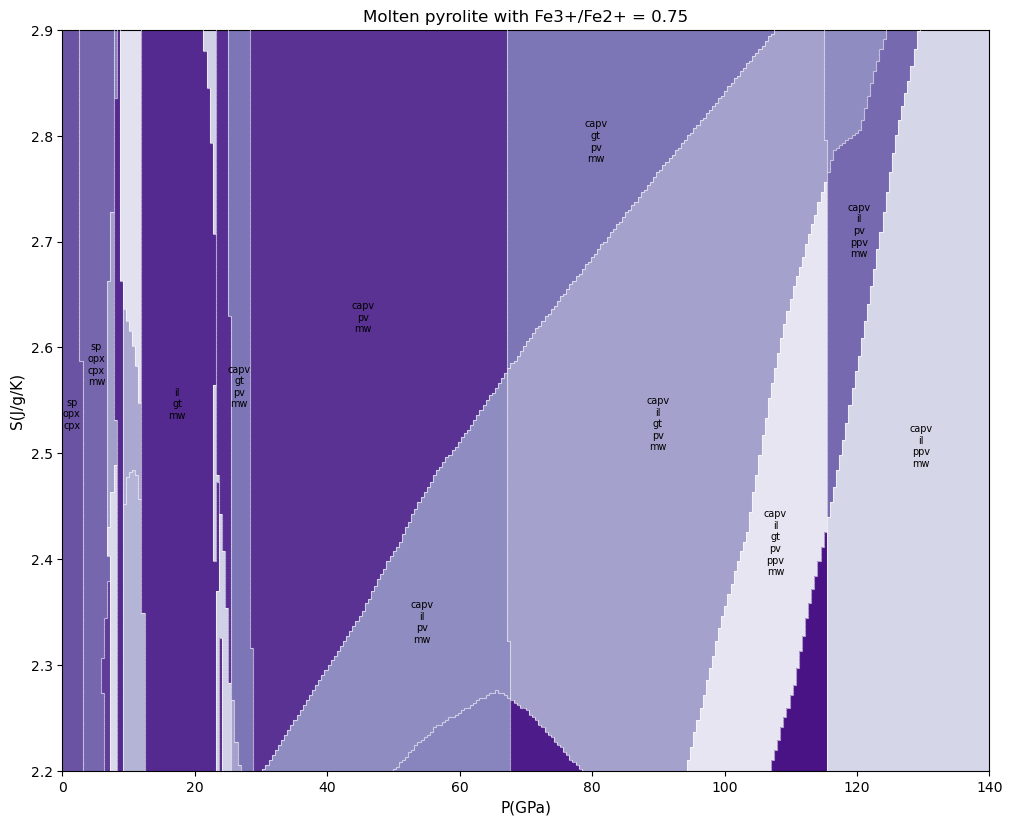

In [14]:
# Animated Phase Diagrams!
import time

input_dict = { #Caracas et al., 2019
    'Si':24,
    'Al':3,
    'Fe':4,
    'Mg':30,
    'Ca':2,
    'Na':1,
}


headers = []
comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
for idx, (element, value) in enumerate(input_dict.items()):
    headers.append(element)
    comp_array[0, idx] = value
    
inputs = grid_sample([[0,140,300],[2.2,2.9,300],[89.5,90.5,50]], comp_array)

independent_variables = ['P(GPa)', 'S(J/g/K)', 'O']

headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', 'O'] + headers

tab = HeFESToEmulatorCPU.parse_input(inputs, headers=headers)[0]

ferrous_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe')+2
ferric_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe3')+2
Ferric_Ratio = tab[:,ferric_column]/ tab[:,ferrous_column]

with torch.no_grad():
    begin_time = time.time()
    threeGrid = HeFESToEmulatorGPU.ForwardMB(inputs, headers=headers, outputs=['phase_moles'])
    end_time = time.time( )
    print(f"Time to run {inputs.shape[0]} assemblages: {end_time - begin_time:.2f} seconds, {(end_time - begin_time) / inputs.shape[0]:.2e} seconds per assemblage")

    independents = inputs[:,:3]
    independents[:,2] = Ferric_Ratio

    animate_phase_diagram(
        coords= independents,
        phases= (threeGrid['phase_moles'] > 0),
        phase_names= [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in HeFESToEmulatorGPU.isentropic_emulator.ml_indexer.all_phases],
        axis_names= independent_variables,
        title_template='Molten pyrolite with Fe3+/Fe2+ = {}' ,
        save_path= 'Phase_Diagram_Demo.gif',
    ) 

print(f"time to animate phase diagram: {time.time()-end_time:.2f} seconds")


In [ ]:
with torch.no_grad():
    begin_time = time.time()
    threeGrid = HeFESToEmulatorGPU.ForwardMB(inputs, headers=headers, outputs=['phase_moles'])
    end_time = time.time( )
    print(f"Time to run {inputs.shape[0]} assemblages: {end_time - begin_time:.2f} seconds, {(end_time - begin_time) / inputs.shape[0]:.2e} seconds per assemblage")

    independents = inputs[:,:3]
    independents[:,2] = Ferric_Ratio

    animate_phase_diagram(
        coords= independents,
        phases= (threeGrid['phase_moles'] > 0),
        phase_names= [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in HeFESToEmulatorGPU.isentropic_emulator.ml_indexer.all_phases],
        axis_names= independent_variables,
        title_template='Molten pyrolite with Fe3+/Fe2+ = {}' ,
        save_path= 'Phase_Diagram_Demo.gif')


MovieWriter ffmpeg unavailable; using Pillow instead.


Adding ferric column...


Processing batches of size 32768:   0%|          | 0/137 [00:00<?, ?it/s]

Phase forcing did not satisfy mass balance even after 3 iterations


Processing batches of size 32768:  42%|████▏     | 57/137 [01:04<01:30,  1.13s/it]


KeyboardInterrupt: 

In [ ]:
HEFESTO_ABBREVIATION_TO_SHORT_NAMES

mappingproxy({'plg': 'plagioclase',
              'sp': 'spinel',
              'ol': 'olivine',
              'wa': 'wadsleyite',
              'ri': 'ringwoodite',
              'opx': 'orthopyroxene',
              'cpx': 'clinopyroxene',
              'wo': 'wollastonite',
              'pwo': 'pseudowollastonite',
              'c2c': 'hp-clinopyroxene',
              'cpv': 'ca-perovskite',
              'il': 'akimotoite',
              'mgil': 'mg-akimotoite',
              'feil': 'fe-akimotoite',
              'gt': 'garnet',
              'qtz': 'quartz',
              'coes': 'coesite',
              'st': 'stishovite',
              'apbo': 'alpha-pbo-type-sio2',
              'seif': 'seifertite',
              'pv': 'bridgmanite',
              'ppv': 'post-perovskite',
              'fp': 'ferropericlase',
              'cf': 'ca-ferrite',
              'nal': 'nal-phase',
              'ky': 'kyanite',
              'neph': 'nepheline',
              'an': 'anorthite',

In [ ]:
input_dict = {
    'Si':24,
    'Al':3,
    'Fe':4,
    'Mg':30,
    'Ca':2,
    'Na':1,
}


headers = []
comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
for idx, (element, value) in enumerate(input_dict.items()):
    headers.append(element)
    comp_array[0, idx] = value
    
independent_variables = ['P(GPa)', 'S(J/g/K)', 'O']

headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', 'O'] + headers

example_input = grid_sample([[20,20,1],[2.5,2.5,1],[89,91,50]], comp_array)
tab = HeFESToEmulatorCPU.parse_input(example_input, headers=headers)[0]

ferrous_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe')+2
ferric_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe3')+2
print(tab[:,ferric_column]/ tab[:,ferrous_column])



Adding ferric column...
tensor([0.0000, 0.0204, 0.0408, 0.0612, 0.0816, 0.1020, 0.1224, 0.1429, 0.1633,
        0.1837, 0.2041, 0.2245, 0.2449, 0.2653, 0.2857, 0.3061, 0.3265, 0.3469,
        0.3673, 0.3878, 0.4082, 0.4286, 0.4490, 0.4694, 0.4898, 0.5102, 0.5306,
        0.5510, 0.5714, 0.5918, 0.6122, 0.6327, 0.6531, 0.6735, 0.6939, 0.7143,
        0.7347, 0.7551, 0.7755, 0.7959, 0.8163, 0.8367, 0.8571, 0.8776, 0.8980,
        0.9184, 0.9388, 0.9592, 0.9796, 1.0000])


In [29]:
torch.pi

3.141592653589793

GPU: 128
Adding ferric column...
[INFO] Adding 'chem_out' to outputs for temperature calculation.
[INFO] Adding 'phase_moles' to outputs for temperature calculation.
0.0000 IO time
Property 'molar_entropy':
torch.Size([128, 18])
tensor([[717.3875, 378.9681, 383.7855,  ...,      nan,  81.0578,  75.0898],
        [719.4812, 375.6087, 383.6117,  ...,      nan,  80.9527,  74.9787],
        [     nan,      nan, 385.3811,  ...,      nan,  81.1734,  75.2120],
        ...,
        [     nan,      nan,      nan,  ...,      nan,  99.4282,  93.8858],
        [     nan,      nan,      nan,  ...,      nan,  99.5292,  93.9726],
        [     nan,      nan,      nan,  ...,      nan,  99.6308,  94.0595]],
       device='cuda:0', dtype=torch.float64)
torch.Size([128, 18])
tensor([[ 8.7880e-02,  1.2553e-05,  8.0582e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2410e-02,  1.6344e-04,  7.4020e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.000

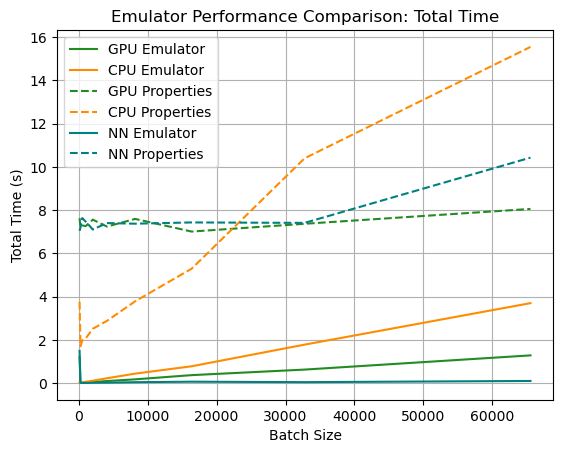

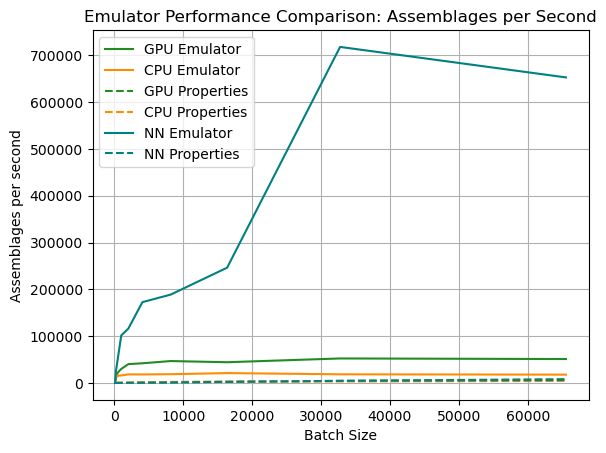

In [ ]:
### Performance Testing

import time



def example_array(batch_size):
    pressures = np.linspace(0,140, batch_size)
    headers = []
    comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
    for idx, (element, value) in enumerate(input_dict.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = np.concatenate([pressures.reshape(-1, 1), np.tile(comp_array, (len(pressures), 1))], axis=1)

    headers = ['P(GPa)'] + headers

    return input_grid, headers

batch_sizes = np.append(np.linspace(128, 2**15, 10, dtype=int), 2**np.linspace(15,18, 20))

GPU_emulator = []
CPU_emulator = []
NN_emulator = []
GPU_properties = []
CPU_properties = []
NN_properties = []


# first GPU
for batch_size in batch_sizes:
    print(f'GPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorGPU.ForwardMB(torch.tensor(input_array, dtype=torch.float32, device='cuda'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    GPU_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cuda').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cuda').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    for i in range(5):
        print(f"Property calculation {i+1}: {time.time() - begin_properties:.4f} seconds")
        output_properties = HeFESToEmulatorGPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cuda'), PT=PT)
    GPU_properties.append(time.time() - begin_properties)

"""for batch_size in batch_sizes:
    print(f'GPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorGPU.ForwardNN(torch.tensor(input_array, dtype=torch.float32, device='cuda'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    NN_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cuda').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cuda').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    output_properties = HeFESToEmulatorGPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cuda'), PT=PT)
    NN_properties.append(time.time() - begin_properties)"""

#Now CPU

for batch_size in batch_sizes:
    print(f'CPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorCPU.ForwardMB(torch.tensor(input_array, dtype=torch.float32, device='cpu'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    CPU_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cpu').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cpu').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    output_properties = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cpu'), PT=PT)
    CPU_properties.append(time.time() - begin_properties)



import matplotlib.pyplot as plt

plt.plot(batch_sizes, GPU_emulator, label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, CPU_emulator, label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, GPU_properties, label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, CPU_properties, label='CPU Properties', color = 'darkorange', linestyle='--')
#plt.plot(batch_sizes, NN_emulator, label='NN Emulator', color = 'teal', linestyle='-')
#plt.plot(batch_sizes, NN_properties, label='NN Properties', color = 'teal', linestyle='--')

plt.xlabel('Batch Size')
plt.ylabel('Total Time (s)')
plt.grid(True)
plt.title('Emulator Performance Comparison: Total Time')
plt.legend()
plt.show()

plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_emulator), label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_emulator), label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_properties), label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_properties), label='CPU Properties', color = 'darkorange', linestyle='--')
#plt.plot(batch_sizes, np.array(batch_sizes)/np.array(NN_emulator), label='NN Emulator', color = 'teal', linestyle='-')
#plt.plot(batch_sizes, np.array(batch_sizes)/np.array(NN_properties), label='NN Properties', color = 'teal', linestyle='--')
plt.xlabel('Batch Size')
plt.ylabel('Assemblages per second')
plt.grid(True)
plt.title('Emulator Performance Comparison: Assemblages per Second')
plt.legend()
plt.show()

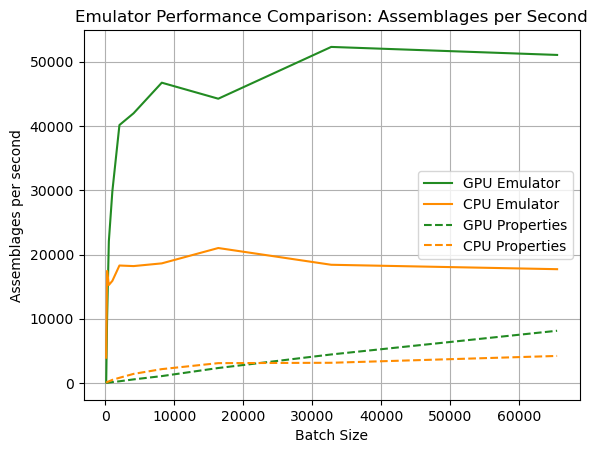

In [4]:

plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_emulator), label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_emulator), label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_properties), label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_properties), label='CPU Properties', color = 'darkorange', linestyle='--')
plt.xlabel('Batch Size')
plt.ylabel('Assemblages per second')
plt.grid(True)
plt.title('Emulator Performance Comparison: Assemblages per Second')
plt.legend()
plt.show()

In [ ]:
generate_phase_diagram(
    coords: np.ndarray,
    phases: np.ndarray,
    phase_names: list[str],
    axis_names: list[str] | None = None,
    *,
    colormap: str = "Purples",
    figsize: tuple[float, float] = (10, 8),
    title: str | None = None,
    ax: "plt.Axes | None" = None,
    small_region_threshold: float = 0.015,
    fontsize: int = 7,
    seed: int = 42,
    boundary_color: str = "white",
    boundary_lw: float = 0.8,
    boundary_alpha: float = 0.6,
    phase_colors: "dict | None" = None,
    apply_tight_layout: bool = True,
) -> tuple["plt.Figure", "plt.Axes"]:

(array([[0.00000000e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.10236220e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [2.20472441e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        ...,
        [1.37795276e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.38897638e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.40000000e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01]]),
 ['P(GPa)', 'Si', 'Mg', 'Fe', 'Ca', 'Al', 'Na', 'Cr', 'O'])

## Phase Diagrams: Ground Truth vs Emulated (DMM_PS)

Visualize which mineral phases are present across T–P space for the DMM composition,
comparing the HeFESTo ground-truth data loaded in cell 2 against the emulator predictions.

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'DMM_PS — Emulated Phase Diagram'}, xlabel='Temperature (K)', ylabel='Pressure (GPa)'>)

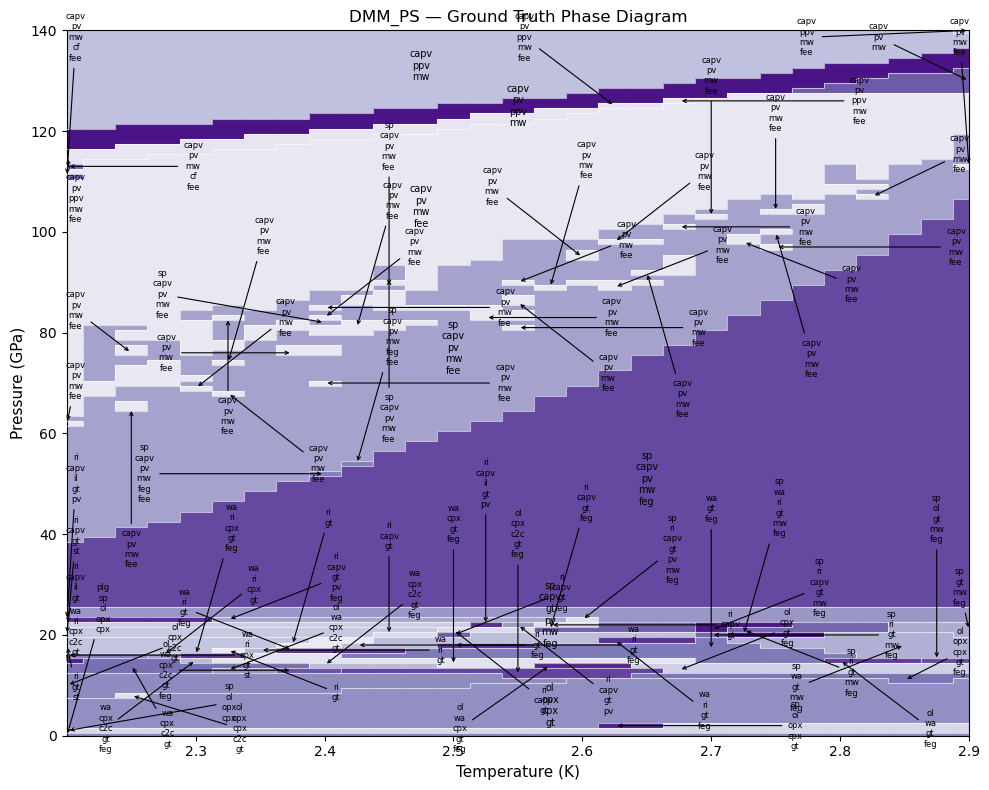

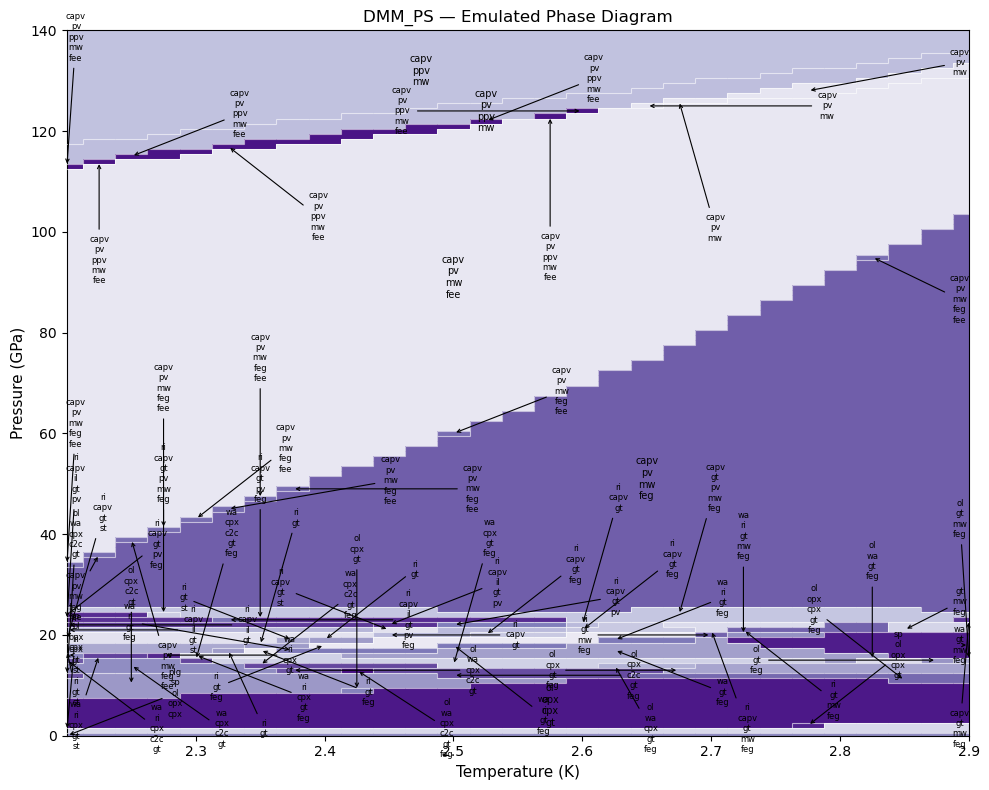

In [10]:
# Phase diagrams: Ground Truth vs Emulated - DMM_PS composition
# Uses generate_phase_diagram() defined in the cell above and
# mass_tables / emulated_mass_tables populated in cell 2.

import numpy as np

def _to_numpy(t):
    if hasattr(t, "detach"):
        return t.detach().cpu().numpy().astype(np.float32)
    return np.asarray(t, dtype=np.float32)

sim_name = "DMM_PS"

coords         = sim_tables[sim_name][["S(J/g/K)", "P(GPa)"]].to_numpy().round(3)
all_phase_names = [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in list(HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases)]

gt_phases = (_to_numpy(mass_tables[sim_name])          > 0).astype(int)
em_phases = (_to_numpy(emulated_mass_tables[sim_name]) > 0).astype(int)

generate_phase_diagram(
    coords=coords,
    phases=gt_phases,
    phase_names=all_phase_names,
    title=f"{sim_name} — Ground Truth Phase Diagram",
)

generate_phase_diagram(
    coords=coords,
    phases=em_phases,
    phase_names=all_phase_names,
    title=f"{sim_name} — Emulated Phase Diagram",
)